# Francesco/Esteves/Valle Model — Análise Completa com Benchmarks Setoriais

Avalia o portfólio **Francesco/Esteves/Valle Model** otimizado contra benchmarks dos **11 setores GICS (Global Industry Classification Standard)**
(retorno equal-weighted de cada setor do S&P 500).

| Modelo | Benchmark de otimização |
|--------|------------------------|
| **Francesco/Esteves/Valle Model** | Benchmark sintético = max_k(Tail_{s/S^k}) dos 11 setores |
| **Roman Model (Scaled)** | SP500 (referência) |
| **Francesco/Esteves/Valle Model (Factors)** | Benchmark sintético dos fatores Fama-French |


---
## Configurações do Experimento
| Parâmetro | Valor |
|------------|--------|
| **Modelo** | TAF-MultiSSD (tafmSSD) — SSD multi-benchmark, benchmark sintético (operador *max_k*) |
| **Formulação** | MIP com lazy constraints (callback CPLEX; variável binária dummy `cb_temp`) |
| **Janela in-sample** | 200 dias (janela deslizante) |
| **Universo** | ~505 ativos componentes do S&P 500 (após remoção de >15% de valores ausentes) |
| **Benchmark** | Sintético = max_k(Tail_{s/S^k}) dos 11 setores GICS |
| **Frequência de rebalanceamento** | A cada 21 dias úteis |
| **Período out-of-sample** | 2024-01-02 a 2024-06-01 |
| **Número de rebalanceamentos** | 5 |
| **Custos de transação** | Nenhum |
| **Lotes mínimos** | Nenhum |

---

**Estrutura:**
1. Setup
2. Carregamento de dados e modelos
3. Contexto de mercado — setores OOS
4. Benchmark sintético OOS — setor dominante
5. Constraint tightness — τ_k por setor por janela
6. Setor dominante por rank
7. Visão geral — portfólio vs setores
8. Drawdown comparativo
9. Métricas OOS — tabela completa
10. Dominância SSD
10b. Dominância SSD — CDFs e integrais cumulativas (Francesco/Esteves/Valle Model)
10c. r_P vs r_B por quantil — análise de cauda
11. Análise risco × retorno
12. Distribuição e correlação
13. Retornos em janela deslizante
14. Sumário executivo


---
## 1. Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import Counter

warnings.filterwarnings('ignore')

ROOT             = Path('..').resolve()
SRC              = ROOT / 'src'
OUTPUT_DIR       = SRC / 'output'
SECTORS_DIR_OUT  = OUTPUT_DIR / 'tafmssd-sectors'
TAFMSSD_DIR      = OUTPUT_DIR / 'tafmssd'
SCSSD_DIR        = OUTPUT_DIR / 'scssd'
DATA_DIR         = SRC / 'data'
SECTORS_DATA_DIR = DATA_DIR / 'sectors'

sys.path.insert(0, str(SRC))
from metrics.stats import compute_ssd_dominance, compute_metrics
from blotter.plots import (
    plot_market_context, plot_performance,
    plot_dominance_overview, plot_dominance_panels,
    plot_risk_return_scatter, plot_return_distribution,
    plot_correlation_matrix, plot_drawdown, plot_rolling_returns,
    plot_portfolio_comparison,
)

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top':  False,   'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 12,
})

AVAILABLE_SECTORS = sorted([f.stem for f in SECTORS_DATA_DIR.glob('*.csv')])
OOS_START  = '2024-01-01'
OOS_END    = '2024-06-01'
RISK_FREE  = 0.05

SECTOR_PALETTE = {
    'BASIC_MATERIALS':             '#8c564b',
    'CONSUMER_CYCLICALS':          '#ff7f0e',
    'CONSUMER_NON_CYCLICALS':      '#bcbd22',
    'ENERGY':                      '#d62728',
    'FINANCIALS':                  '#1f77b4',
    'HEALTHCARE':                  '#2ca02c',
    'INDUSTRIALS':                 '#7f7f7f',
    'REAL_ESTATE':                 '#9467bd',
    'TECHNOLOGY':                  '#17becf',
    'TELECOMMUNICATIONS_SERVICES': '#e377c2',
    'UTILITIES':                   '#aec7e8',
}

print(f'ROOT: {ROOT}')
print(f'Setores disponíveis ({len(AVAILABLE_SECTORS)}): {AVAILABLE_SECTORS}')


ROOT: /media/toni/Dados/Git/ssd-multi
Setores disponíveis (11): ['BASIC_MATERIALS', 'CONSUMER_CYCLICALS', 'CONSUMER_NON_CYCLICALS', 'ENERGY', 'FINANCIALS', 'HEALTHCARE', 'INDUSTRIALS', 'REAL_ESTATE', 'TECHNOLOGY', 'TELECOMMUNICATIONS_SERVICES', 'UTILITIES']


---
## Configuração do Experimento

---
## 2. Carregamento de dados e modelos

In [2]:
# ── Market data (assets + SP500) ──────────────────────────────────────────────
market        = pd.read_csv(DATA_DIR / 'marketData.csv', parse_dates=['Date'])
market.set_index('Date', inplace=True)
market_prices = market.dropna(how='all').abs()
market_returns = market_prices.diff() / market_prices.shift(1)
market_returns = market_returns.iloc[1:]

# ── Sector equal-weighted returns ──────────────────────────────────────────────
def load_sector_returns(sectors_dir, selected, index):
    frames = {}
    for sector in selected:
        prices = pd.read_csv(sectors_dir / f'{sector}.csv', parse_dates=['Date'])
        prices.set_index('Date', inplace=True)
        prices = prices[prices.columns[prices.isnull().mean() <= 0.15]]
        prices = prices.ffill().bfill().abs()
        ret    = prices.diff() / prices.shift(1)
        ret    = ret.iloc[1:]
        frames[sector] = ret.mean(axis=1)
    return pd.DataFrame(frames).reindex(index)

sector_returns = load_sector_returns(SECTORS_DATA_DIR, AVAILABLE_SECTORS, market_returns.index)

# ── OOS sector series ──────────────────────────────────────────────────────────
sector_oos = {}
for s in AVAILABLE_SECTORS:
    ret = sector_returns.loc[OOS_START:OOS_END, s].dropna()
    cum = (1 + ret).cumprod()
    sector_oos[s] = {'norm': (cum / cum.iloc[0]), 'ret': ret}

idx = sector_oos[AVAILABLE_SECTORS[0]]['norm'].index

# SP500 OOS (for reference only)
sp500_oos  = market_prices.loc[OOS_START:OOS_END, 'SP500']
sp500_norm = (sp500_oos / sp500_oos.iloc[0]).reindex(idx)
sp500_ret  = market_returns.loc[OOS_START:OOS_END, 'SP500'].reindex(idx)

print(f'Market data  : {market_prices.shape}')
print(f'OOS          : {idx[0].date()} → {idx[-1].date()}  ({len(idx)} dias)')
print(f'Setores      : {sector_returns.shape}')


Market data  : (305, 509)
OOS          : 2024-01-02 → 2024-05-31  (105 dias)
Setores      : (304, 11)


In [3]:
# ── Load model portfolios ──────────────────────────────────────────────────────
def load_port(path, label):
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    s  = df.iloc[:, 0].reindex(idx).ffill()
    return s.rename(label)

models = {}

# Francesco/Esteves/Valle Model (sector synthetic benchmark)
sec_path = SECTORS_DIR_OUT / 'portfolio_tafmssd_sectors.csv'
if sec_path.exists():
    models['Francesco/Esteves/Valle Model'] = load_port(sec_path, 'Francesco/Esteves/Valle Model')

# Roman Model (Scaled) — SP500 reference
scssd_path = SCSSD_DIR / 'portfolio_scssd.csv'
if scssd_path.exists():
    models['Roman Model (Scaled)'] = load_port(scssd_path, 'Roman Model (Scaled)')

# tafmSSD (factor-based, for comparison)
taf_path = TAFMSSD_DIR / 'portfolio_tafmssd.csv'
if taf_path.exists():
    models['Francesco/Esteves/Valle Model (Factors)'] = load_port(taf_path, 'Francesco/Esteves/Valle Model (Factors)')

# OOS synthetic sector benchmark
synth_path = SECTORS_DIR_OUT / 'synthetic_benchmark_oos.csv'
if synth_path.exists():
    synth_oos = pd.read_csv(synth_path, index_col=0, parse_dates=True).squeeze().reindex(idx).ffill()
else:
    # Same formulation as the experiment: tau_oos[s] = max_k(Tail_{s/S_k}(I_k))
    # over OOS sector returns; implied sorted returns dated by quantile matching
    # against the cross-sector mean return.
    ret_oos   = pd.DataFrame({s: sector_oos[s]['ret'] for s in AVAILABLE_SECTORS}).reindex(idx)
    S_oos     = len(ret_oos)
    tails     = np.column_stack([np.cumsum(np.sort(ret_oos[s].values)) / S_oos
                                 for s in AVAILABLE_SECTORS])
    tau_oos   = tails.max(axis=1)
    abs_oos   = np.diff(S_oos * tau_oos, prepend=0.0)
    order     = ret_oos.mean(axis=1).rank(method='first').astype(int) - 1
    synth_ret = pd.Series(abs_oos[order.values], index=ret_oos.index)
    synth_oos = (1 + synth_ret).cumprod()
    synth_oos = synth_oos / synth_oos.iloc[0]

print(f'\nModelos carregados ({len(models)}):')
for k, v in models.items():
    print(f'  {k:<40}  final = {v.iloc[-1]:.4f}  ({(v.iloc[-1]-1)*100:+.2f}%)')



Modelos carregados (3):
  Francesco/Esteves/Valle Model             final = 1.6092  (+60.92%)
  Roman Model (Scaled)                      final = 1.4911  (+49.11%)
  Francesco/Esteves/Valle Model (Factors)   final = 1.2230  (+22.30%)


---
## 3. Contexto de mercado — setores OOS

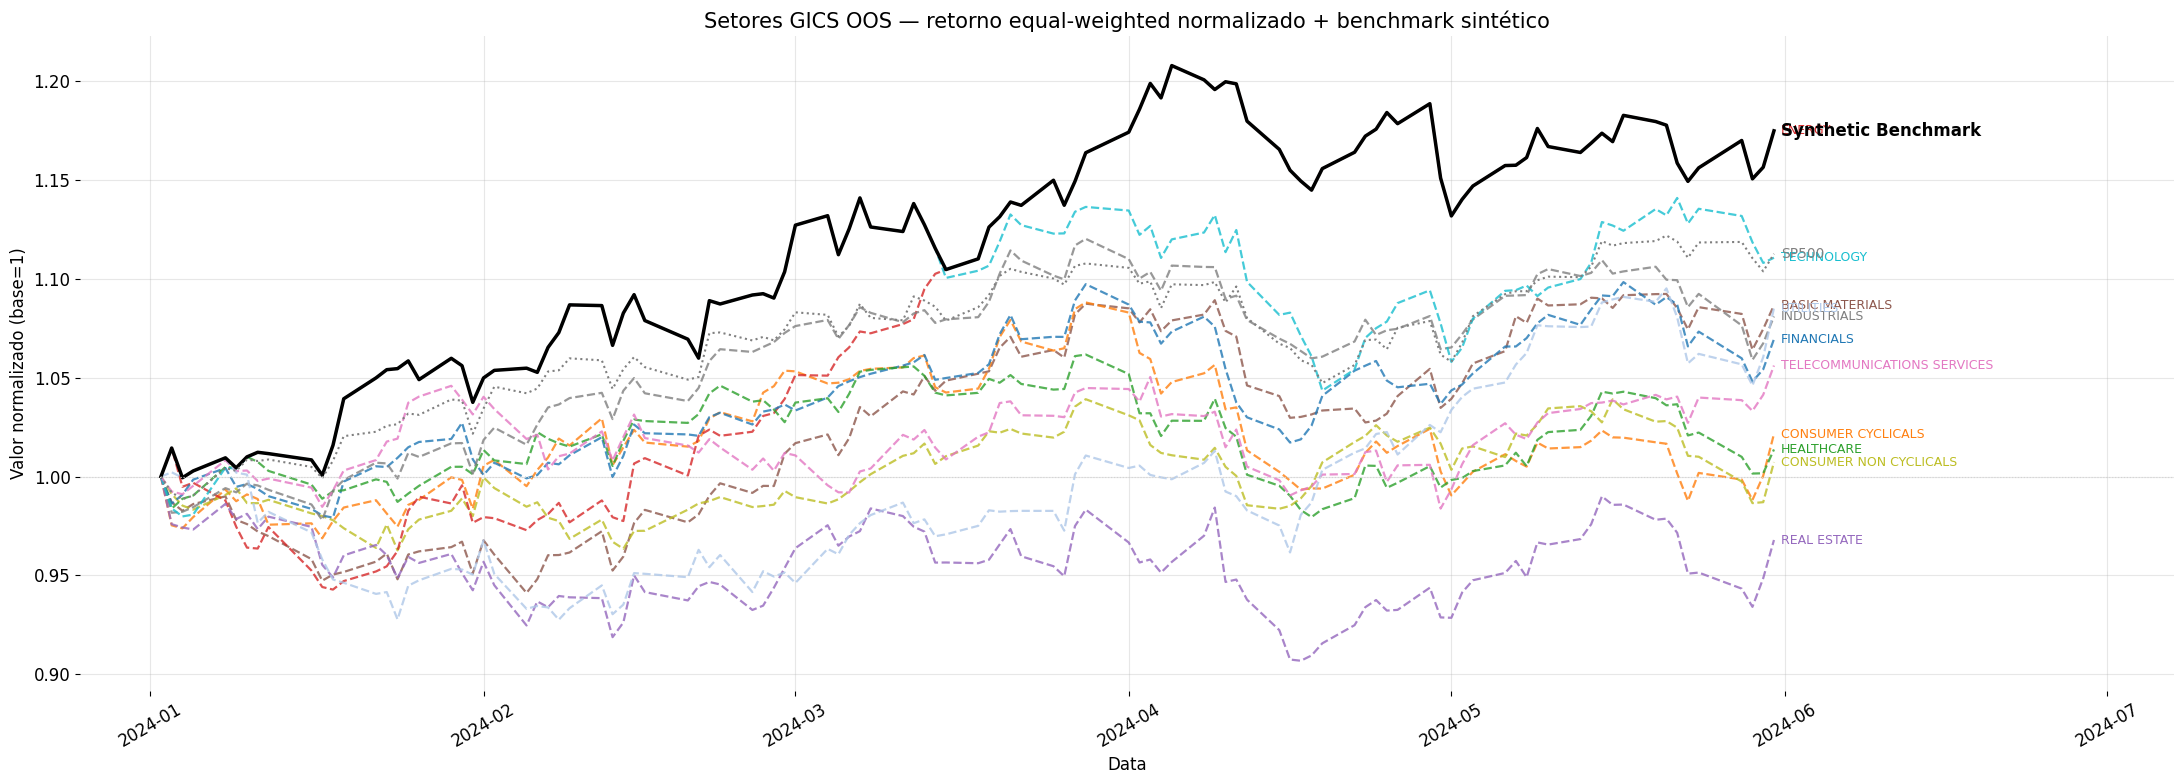

In [4]:
fig, ax = plt.subplots(figsize=(22, 8))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')

for sector in AVAILABLE_SECTORS:
    norm  = sector_oos[sector]['norm']
    color = SECTOR_PALETTE[sector]
    ax.plot(norm.index, norm.values, linewidth=1.6, linestyle='--', color=color, alpha=0.8)
    ax.annotate(sector.replace('_', ' '), xy=(norm.index[-1], norm.iloc[-1]),
                xytext=(5, 0), textcoords='offset points', va='center',
                fontsize=9, color=color)

ax.plot(synth_oos.index, synth_oos.values, linewidth=2.5, color='black')
ax.annotate('Synthetic Benchmark', xy=(synth_oos.index[-1], synth_oos.iloc[-1]),
            xytext=(5, 0), textcoords='offset points', va='center',
            fontsize=12, color='black', fontweight='bold')

ax.plot(sp500_norm.index, sp500_norm.values, linewidth=1.5, color='gray', linestyle=':')
ax.annotate('SP500', xy=(sp500_norm.index[-1], sp500_norm.iloc[-1]),
            xytext=(5, 0), textcoords='offset points', va='center', fontsize=10, color='gray')

ax.axhline(1.0, color='lightgray', linewidth=0.8, linestyle=':')
x_min, x_max = ax.get_xlim()
ax.set_xlim(x_min, x_max + (x_max - x_min) * 0.18)
ax.set_title('Setores GICS OOS — retorno equal-weighted normalizado + benchmark sintético', fontsize=15)
ax.set_xlabel('Data'); ax.set_ylabel('Valor normalizado (base=1)')
ax.tick_params(axis='x', rotation=30)
for sp in ax.spines.values(): sp.set_visible(False)
plt.tight_layout()
plt.savefig(SECTORS_DIR_OUT / 'sectors_overview.pdf', bbox_inches='tight')
plt.show()


**Contexto de mercado (visão geral dos setores OOS)**

O gráfico apresenta a performance normalizada dos 11 setores GICS durante o período out-of-sample. A linha preta sólida (Synthetic Benchmark) é a capitalização da distribuição sintética construída com a mesma formulação usada na otimização — $\max_k\bigl(\mathrm{Tail}_{s/S^k}(R(I^k))\bigr)$ sobre os retornos setoriais OOS — com os retornos implícitos atribuídos às datas por quantile matching (o pior retorno sintético cai no pior dia do retorno médio dos setores). A amplitude de dispersão entre os setores revela a heterogeneidade do ambiente OOS: um portfólio bem otimizado deve superar a maioria dos setores individualmente; o Synthetic Benchmark encerra o período próximo do melhor setor — em cada nível de cauda ele adota a exigência do setor mais rigoroso, mas, por ser uma distribuição (e não um envelope de trajetórias), pode ser cruzado pontualmente por setores individuais. Setores abaixo de 1.0 representam perdas absolutas no período e impuseram restrições SSD mais frouxas ao modelo. O SP500 (pontilhado cinza) serve de referência de mercado amplo; quando o Synthetic Benchmark se posiciona nitidamente acima do SP500, o ambiente criado pelos setores foi mais exigente que o mercado como um todo — endurecendo as restrições que o portfólio teve de satisfazer a cada rebalanceamento.

**Fórmula de normalização:**

$$\text{norm}_s(t) = \prod_{i=1}^{t}\bigl(1 + r_{s,i}\bigr) = \frac{P_s(t)}{P_s(0)}, \qquad \tau_{\text{oos}}[s] = \max_k\left(\mathrm{Tail}_{\frac{s}{S^k}}\bigl(R(I^k)\bigr)\right), \quad r^{(s)}_{\text{synth}} = S\,\tau_{\text{oos}}[s] - S\,\tau_{\text{oos}}[s-1]$$

onde $r_{s,i}$ é o retorno equal-weighted do setor $s$ no dia $i$ (média dos retornos de seus constituintes) e $P_s(t)$ seu índice de retorno acumulado. Cada série é rebaseada para 1.0 no primeiro dia OOS; o Synthetic Benchmark capitaliza os retornos implícitos $r^{(s)}_{\text{synth}}$ do envelope de tail expectations, datados por quantile matching contra o retorno médio dos setores.

In [ ]:
fig, ax = plt.subplots(figsize=(22, 8))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')

for sector in AVAILABLE_SECTORS:
    norm  = sector_oos[sector]['norm']
    color = SECTOR_PALETTE[sector]
    ax.plot(norm.index, norm.values, linewidth=1.6, linestyle='--', color=color, alpha=0.8)
    ax.annotate(sector.replace('_', ' '), xy=(norm.index[-1], norm.iloc[-1]),
                xytext=(5, 0), textcoords='offset points', va='center',
                fontsize=9, color=color)


ax.plot(sp500_norm.index, sp500_norm.values, linewidth=1.5, color='gray', linestyle=':')
ax.annotate('SP500', xy=(sp500_norm.index[-1], sp500_norm.iloc[-1]),
            xytext=(5, 0), textcoords='offset points', va='center', fontsize=10, color='gray')

ax.axhline(1.0, color='lightgray', linewidth=0.8, linestyle=':')
x_min, x_max = ax.get_xlim()
ax.set_xlim(x_min, x_max + (x_max - x_min) * 0.18)
ax.set_title('Setores GICS OOS — retorno equal-weighted normalizado (sem benchmark sintético)', fontsize=15)
ax.set_xlabel('Data'); ax.set_ylabel('Valor normalizado (base=1)')
ax.tick_params(axis='x', rotation=30)
for sp in ax.spines.values(): sp.set_visible(False)
plt.tight_layout()
plt.savefig(SECTORS_DIR_OUT / 'sectors_overview_no_synth.pdf', bbox_inches='tight')
plt.show()


**Contexto de mercado sem o Synthetic Benchmark**

Mesma visão do gráfico anterior, porém sem o envelope sintético: a linha preta dominante é removida para evidenciar a dispersão entre os 11 setores GICS e a posição relativa do SP500 (pontilhado cinza). Sem o envelope, fica mais fácil ler quais setores lideram em cada trecho do período OOS — informação que no gráfico anterior fica visualmente comprimida pela linha preta do Synthetic Benchmark.

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd-sectors/market_context_basic_materials.pdf


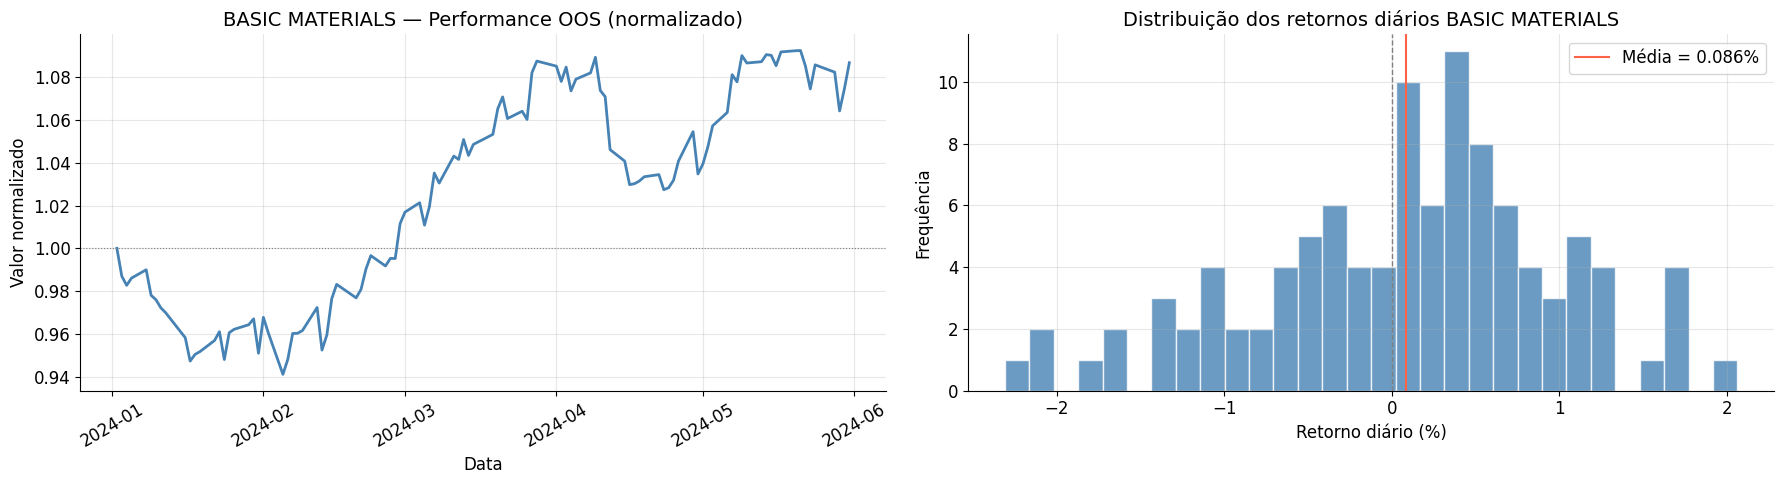

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd-sectors/market_context_consumer_cyclicals.pdf


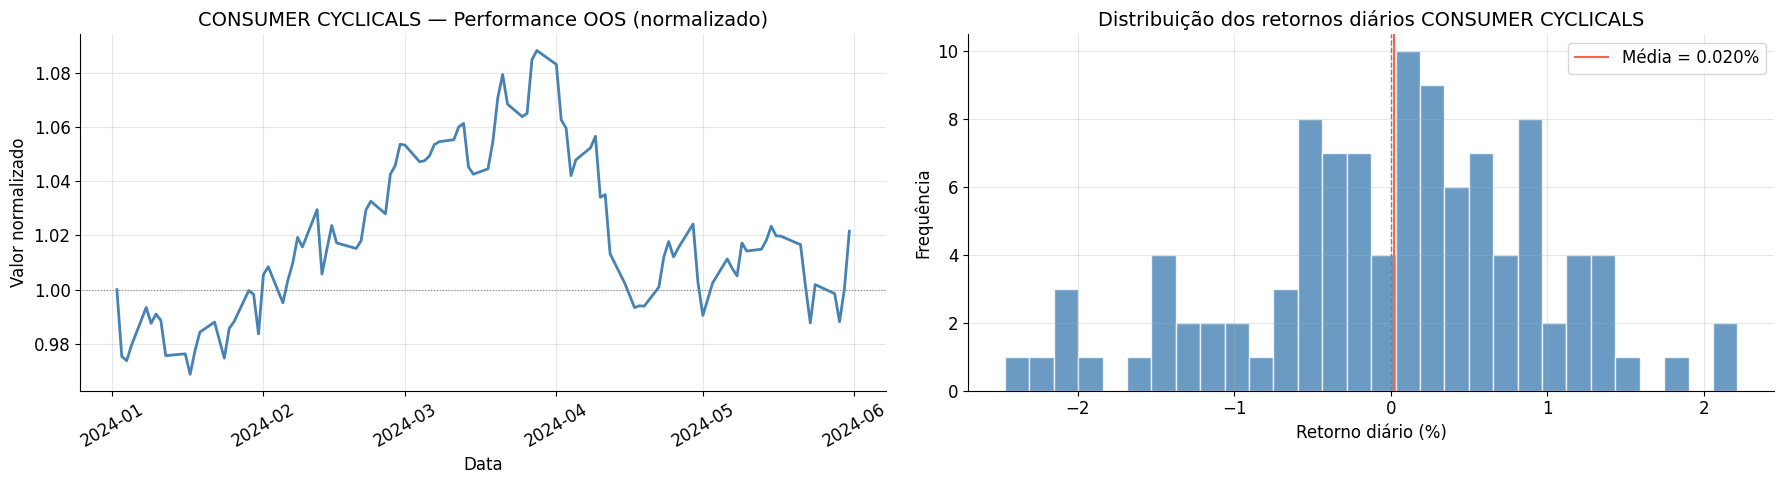

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd-sectors/market_context_consumer_non_cyclicals.pdf


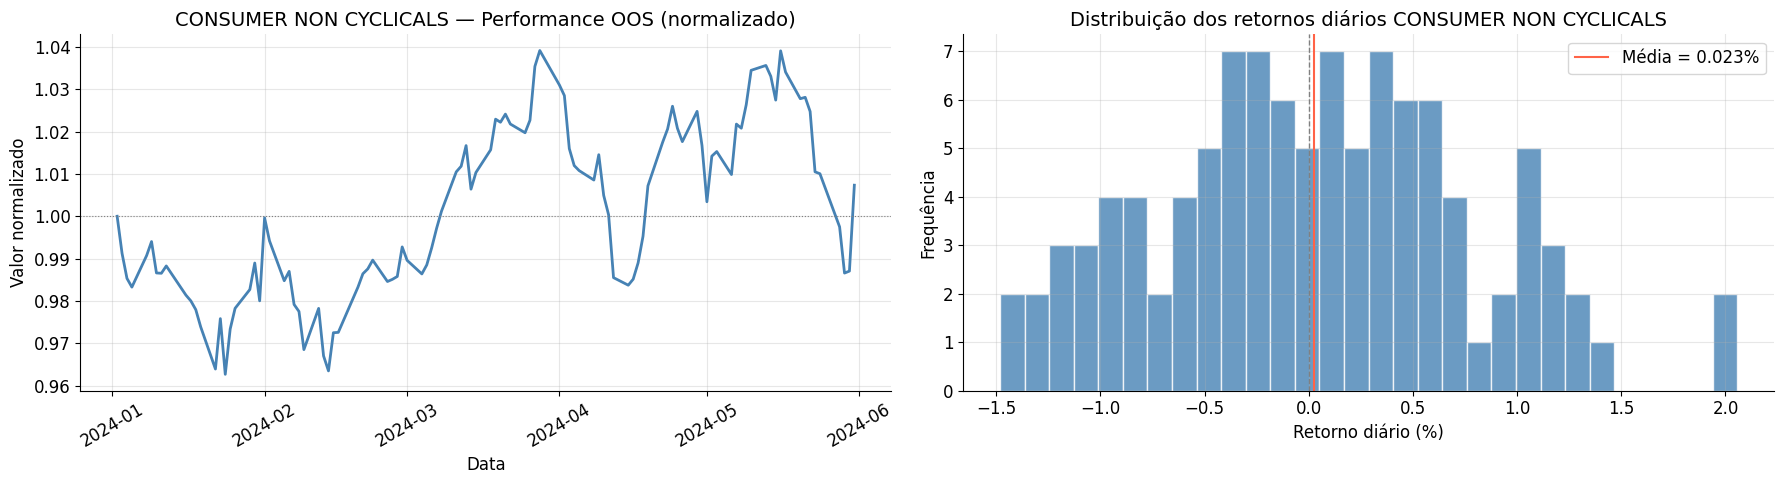

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd-sectors/market_context_energy.pdf


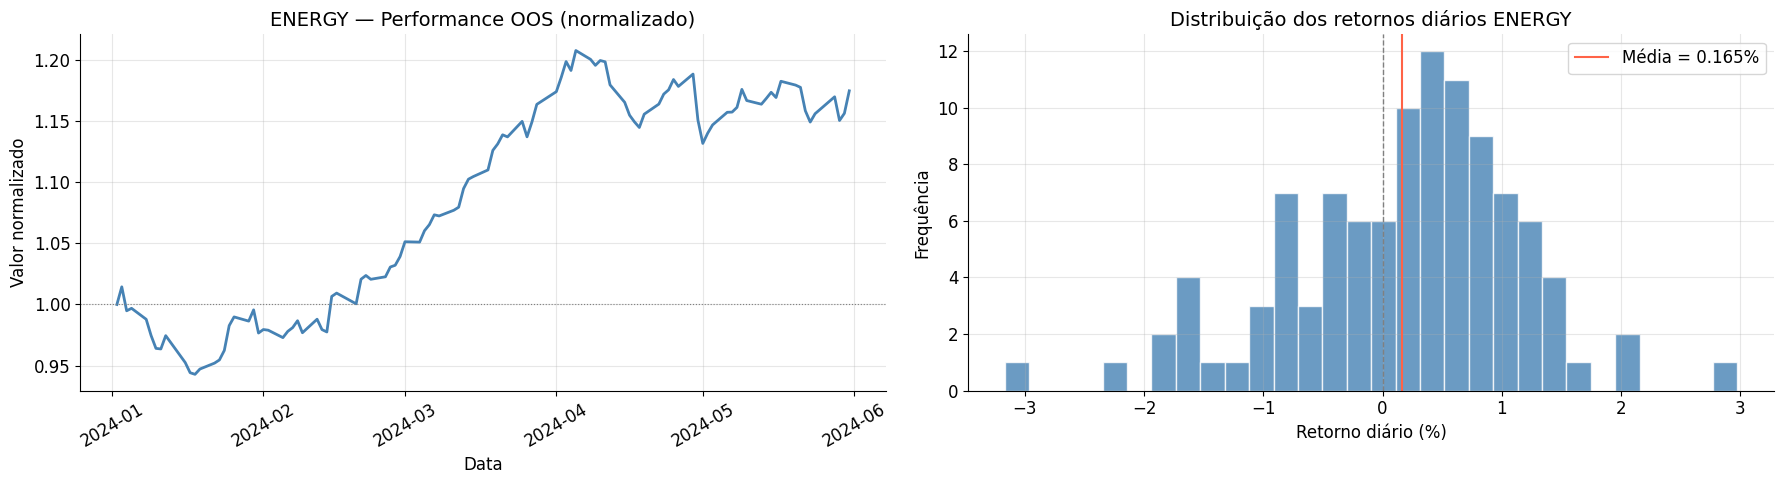

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd-sectors/market_context_financials.pdf


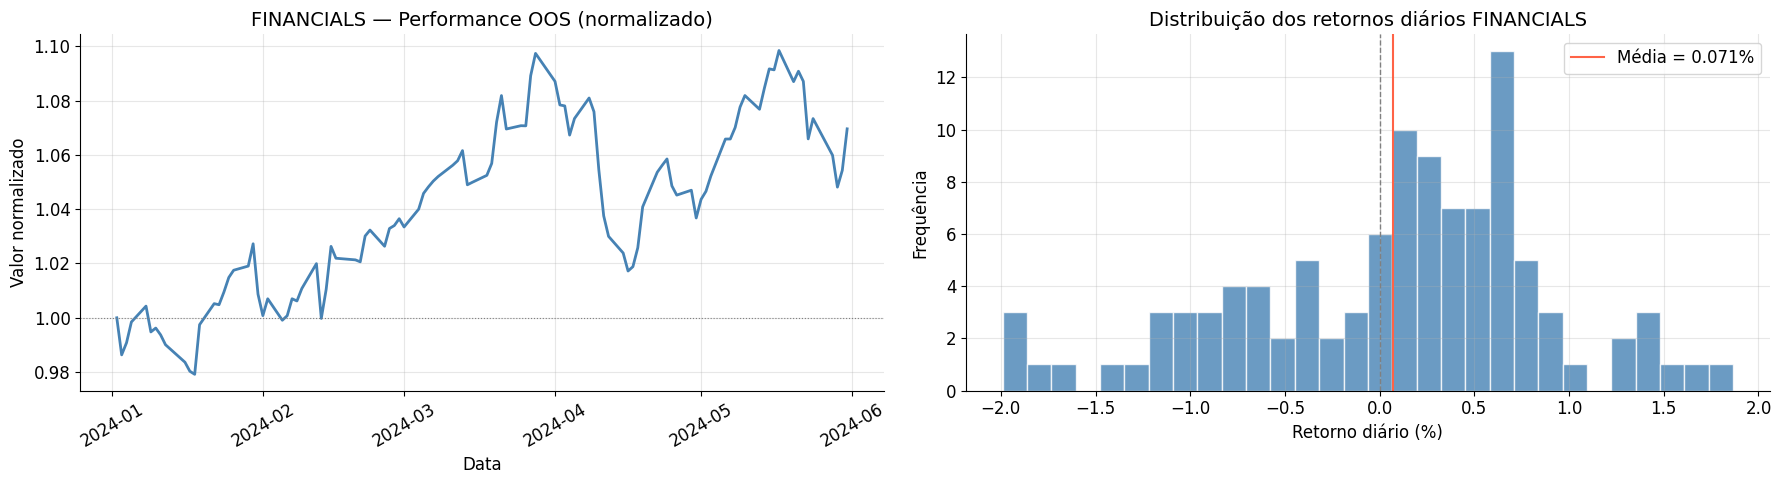

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd-sectors/market_context_healthcare.pdf


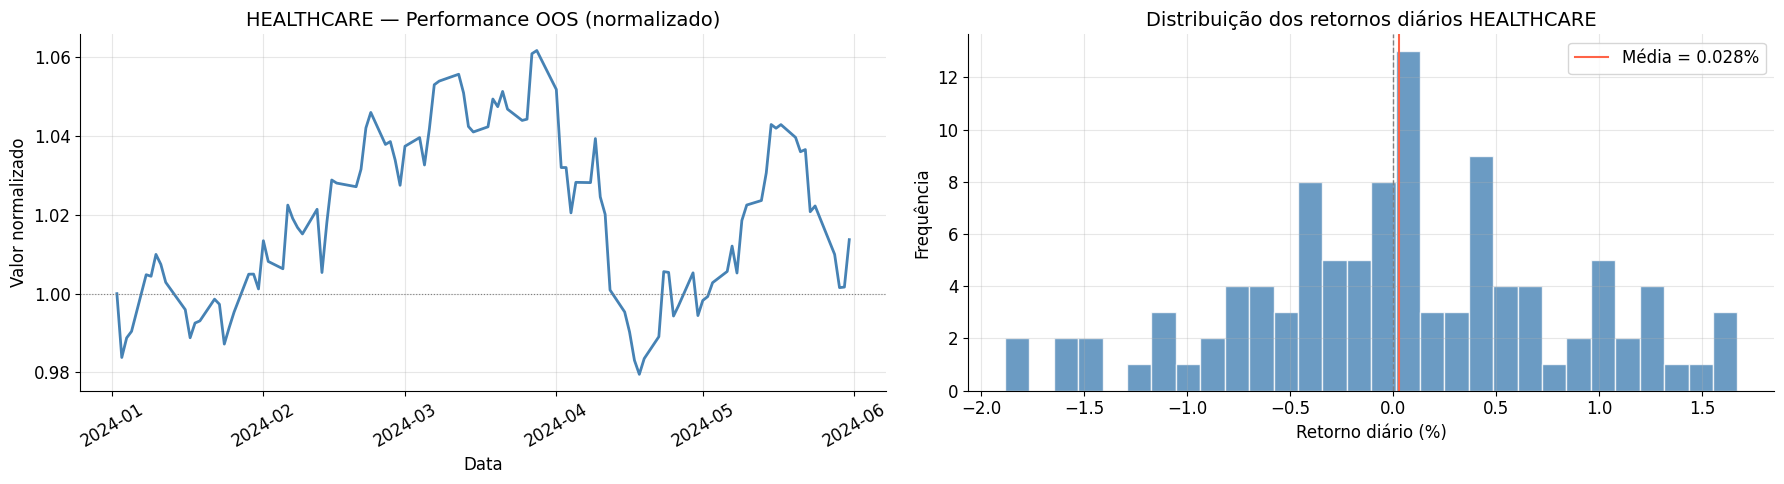

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd-sectors/market_context_industrials.pdf


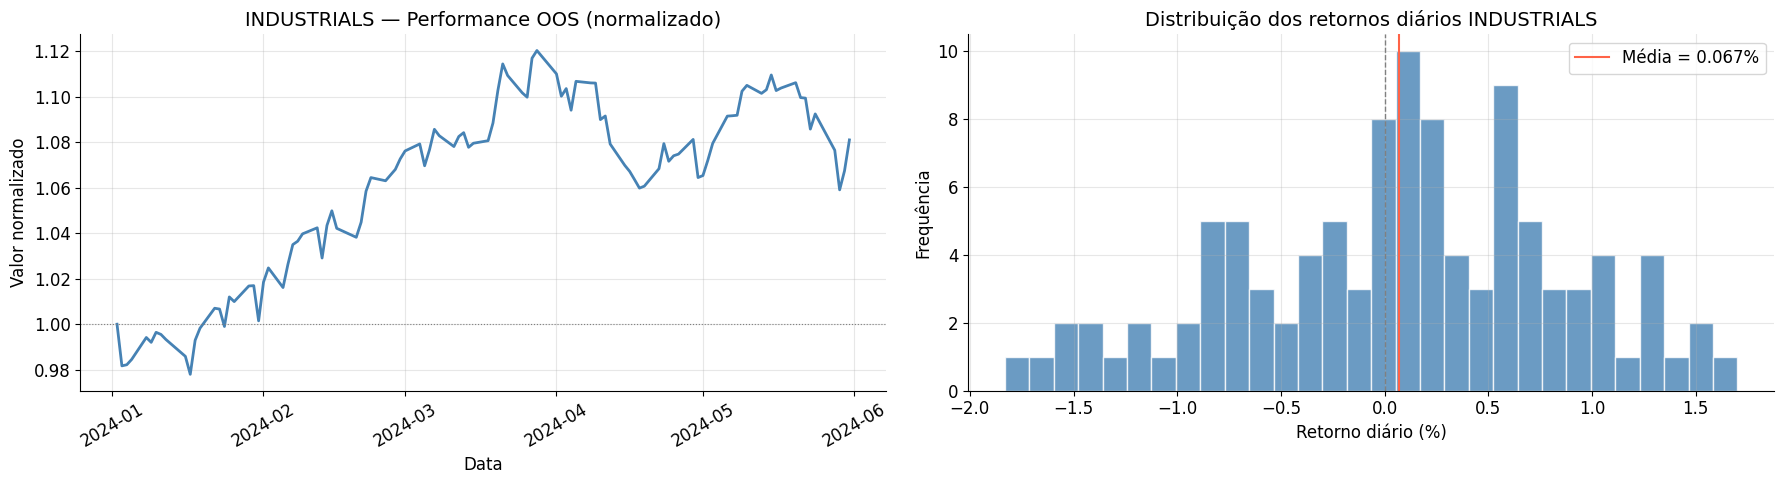

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd-sectors/market_context_real_estate.pdf


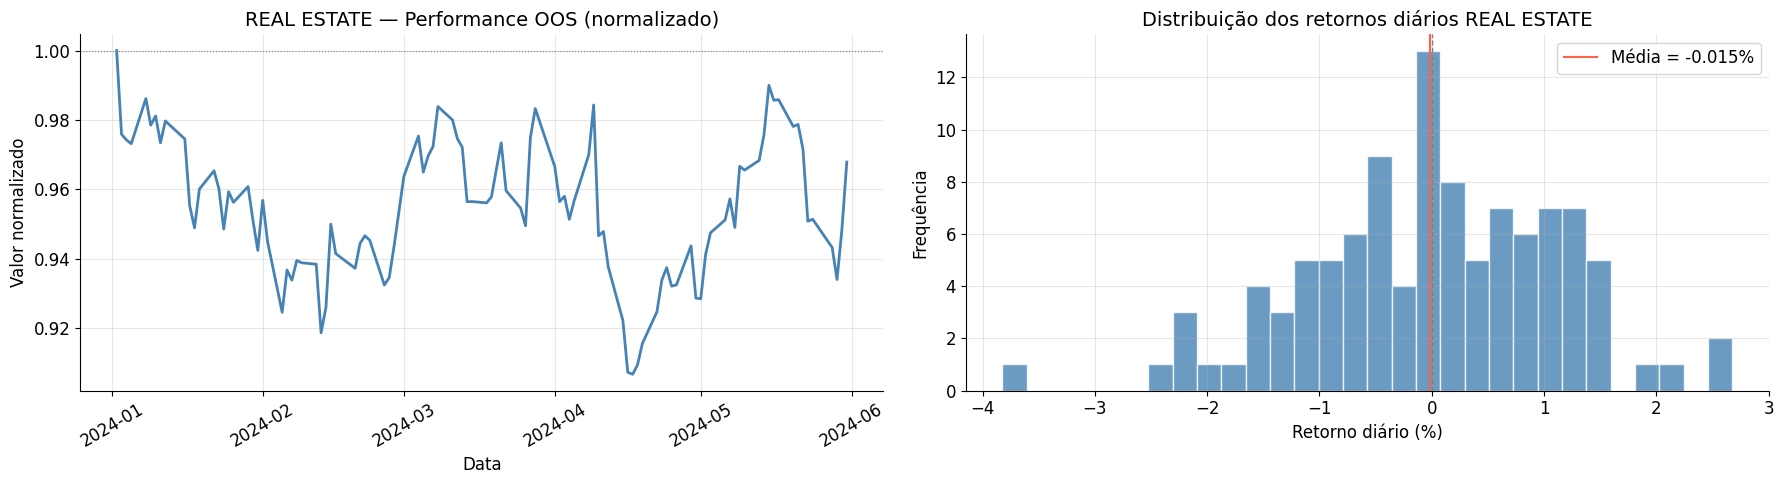

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd-sectors/market_context_technology.pdf


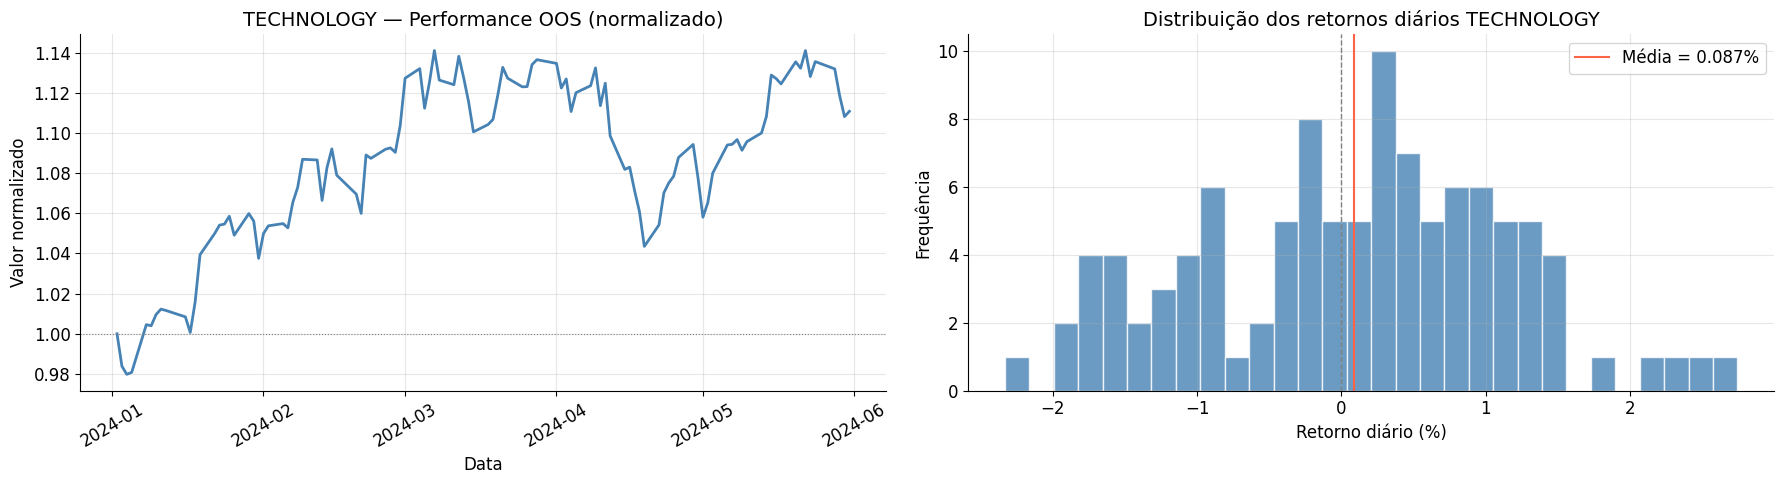

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd-sectors/market_context_telecommunications_services.pdf


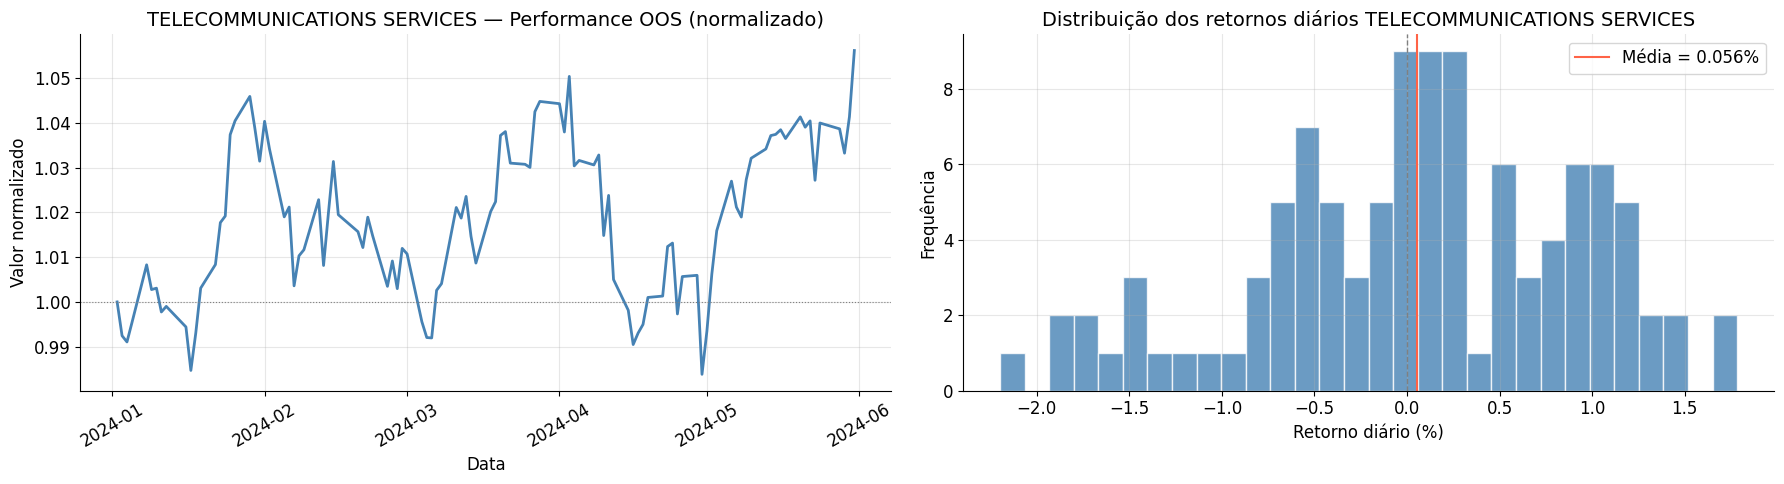

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd-sectors/market_context_utilities.pdf


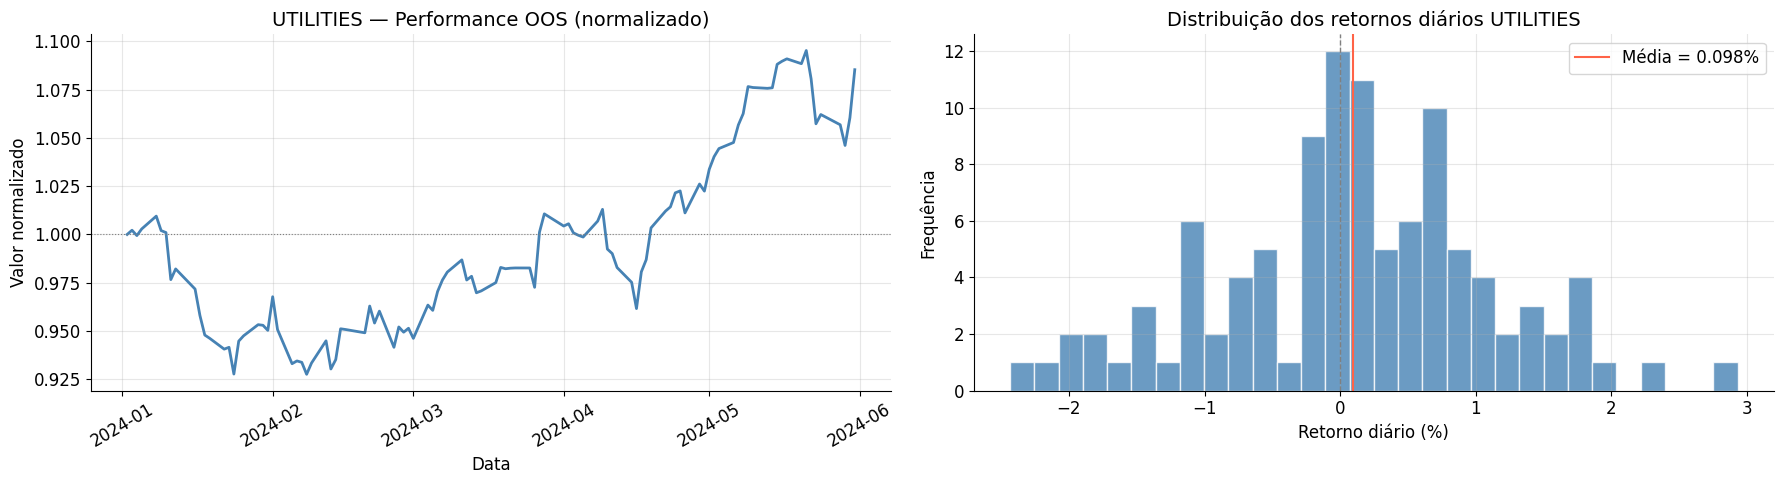

In [5]:
for sector in AVAILABLE_SECTORS:
    plot_market_context(
        sector_oos[sector]['norm'], sector_oos[sector]['ret'],
        benchmark_name=sector.replace('_', ' '),
        save_path=SECTORS_DIR_OUT / f'market_context_{sector.lower()}.pdf',
    )


**Contexto de mercado individual por setor**

Cada painel combina a série normalizada com a distribuição de retornos diários de um setor. Setores com caudas largas nos retornos criam as restrições SSD mais exigentes: o portfólio precisa acumular retornos suficientes mesmo nos piores cenários daquele setor, de modo que a integral cumulativa dos retornos ordenados do portfólio domine a correspondente integral do setor. Setores com tendência positiva acentuada no período OOS são os candidatos mais prováveis a ter sido o binding constraint do Synthetic Benchmark em alguma janela de treino. Setores com retornos persistentemente negativos (série abaixo de 1.0) raramente foram binding — o portfólio os dominou com ampla margem, tornando suas restrições SSD virtualmente inativas durante a otimização.


---
## 3b. Setor dominante por dia OOS

In [6]:
ret_df   = pd.DataFrame({s: sector_oos[s]['ret'] for s in AVAILABLE_SECTORS}).reindex(idx)
dom_day  = ret_df.idxmax(axis=1)

print('Frequência de dominância diária (qual setor tem maior retorno em cada dia OOS):')
for s, n in dom_day.value_counts().items():
    print(f'  {s:<38}  {n:3d} dias  ({n/len(idx)*100:.1f}%)')


Frequência de dominância diária (qual setor tem maior retorno em cada dia OOS):
  ENERGY                                   23 dias  (21.9%)
  TECHNOLOGY                               22 dias  (21.0%)
  UTILITIES                                16 dias  (15.2%)
  CONSUMER_NON_CYCLICALS                    9 dias  (8.6%)
  CONSUMER_CYCLICALS                        8 dias  (7.6%)
  REAL_ESTATE                               8 dias  (7.6%)
  BASIC_MATERIALS                           6 dias  (5.7%)
  FINANCIALS                                5 dias  (4.8%)
  TELECOMMUNICATIONS_SERVICES               4 dias  (3.8%)
  HEALTHCARE                                3 dias  (2.9%)
  INDUSTRIALS                               1 dias  (1.0%)


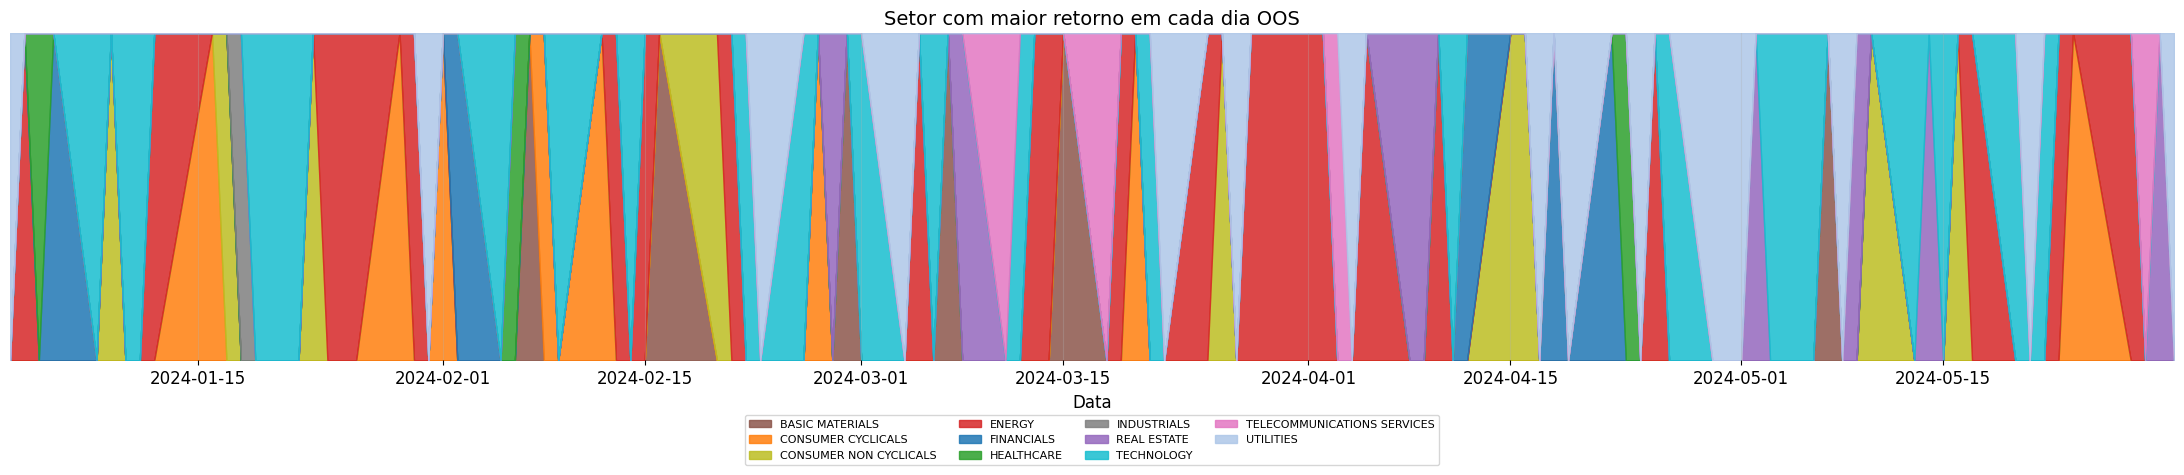

In [7]:
# Stacked area chart showing daily dominance
fig, ax = plt.subplots(figsize=(22, 5))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')

bottom = np.zeros(len(idx))
for sector in AVAILABLE_SECTORS:
    mask = (dom_day == sector).astype(float).values
    ax.fill_between(idx, bottom, bottom + mask,
                    color=SECTOR_PALETTE[sector], alpha=0.85,
                    label=sector.replace('_', ' '))
    bottom += mask

ax.set_xlim(idx[0], idx[-1])
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_title('Setor com maior retorno em cada dia OOS', fontsize=14)
ax.set_xlabel('Data')
ax.legend(fontsize=8, ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.15))
for sp in ax.spines.values(): sp.set_visible(False)
plt.tight_layout()
plt.savefig(SECTORS_DIR_OUT / 'dominant_sector_daily.pdf', bbox_inches='tight')
plt.show()


**Setor dominante por dia OOS**

O gráfico de área empilhada revela qual setor teve o maior retorno em cada dia do período OOS, determinando qual componente "puxou" o Synthetic Benchmark para cima naquela jornada. Quando um único setor domina uma fração extensa do período (bloco de cor uniforme), o Synthetic Benchmark é na prática monosetorial no OOS — e o portfólio foi essencialmente pressionado por aquele benchmark específico. Alta fragmentação de cores indica que a liderança rotaciona entre setores: o Synthetic Benchmark é genuinamente multi-setorial, tornando a dominância SSD mais difícil de garantir em toda a distribuição. Setores com mais de 40% dos dias (conforme impresso na célula anterior) tendem a ser os binding constraints durante o walk-forward. Transições abruptas de setor dominante frequentemente coincidem com eventos de mercado — choques setoriais, rotações de estilo — que o modelo não pôde antecipar in-sample, sendo um ponto de atenção para a robustez OOS.


---
## 4. Benchmark sintético OOS — análise detalhada

O benchmark sintético OOS usa a mesma formulação do in-sample: τ_oos[s] = max_k(Tail_{s/S_k}(I_k)) sobre os retornos setoriais OOS; os retornos implícitos diff(S·τ) são datados por quantile matching contra o retorno médio dos setores.
In-sample, `synth_tau` (= max_k Tail) e os retornos implícitos `synth_abs` são salvos nos `synthetic_bench-*.csv`.


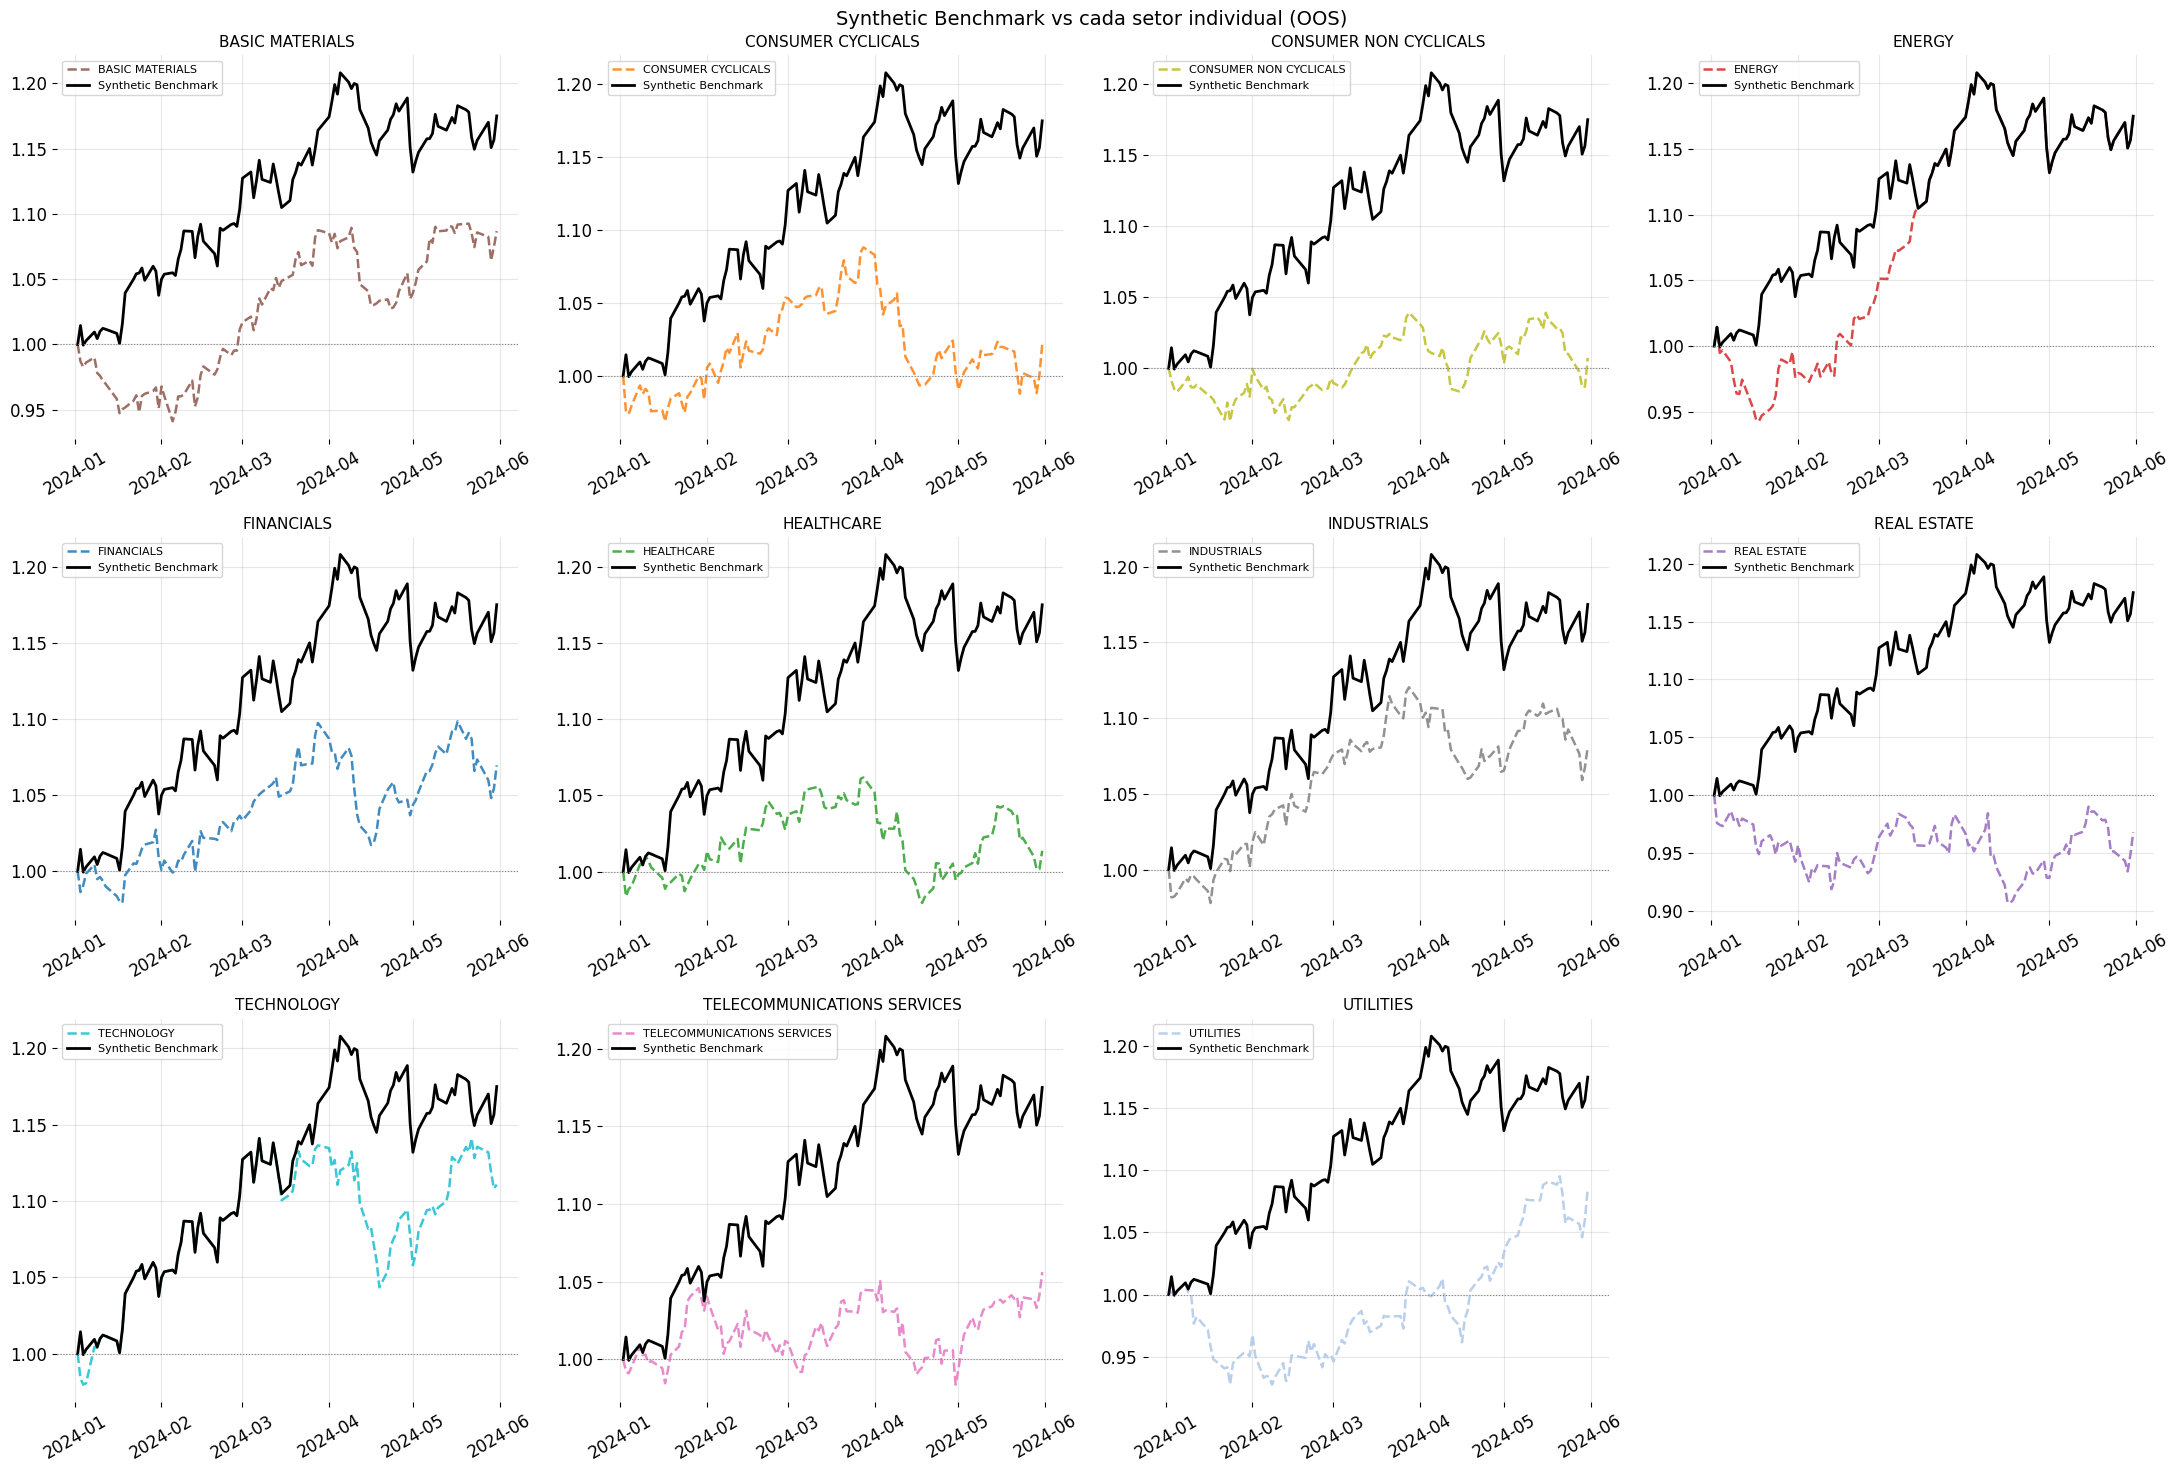

In [8]:
# Synthetic vs each sector (grid 3x4)
n_sectors = len(AVAILABLE_SECTORS)
n_cols_g  = 4
n_rows_g  = (n_sectors + n_cols_g - 1) // n_cols_g

fig, axes = plt.subplots(n_rows_g, n_cols_g, figsize=(22, n_rows_g * 5))
fig.patch.set_facecolor('white')
axes_flat = axes.flatten()

for i, sector in enumerate(AVAILABLE_SECTORS):
    ax = axes_flat[i]; ax.set_facecolor('white')
    norm  = sector_oos[sector]['norm']
    color = SECTOR_PALETTE[sector]
    ax.plot(norm.index, norm.values, color=color, linewidth=1.8, linestyle='--', alpha=0.85,
            label=sector.replace('_', ' '))
    ax.plot(synth_oos.index, synth_oos.values, color='black', linewidth=2.0, label='Synthetic Benchmark')
    ax.axhline(1.0, color='gray', linewidth=0.8, linestyle=':')
    ax.set_title(sector.replace('_', ' '), fontsize=11)
    ax.tick_params(axis='x', rotation=30)
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.legend(fontsize=8)

for ax in axes_flat[n_sectors:]:
    ax.set_visible(False)

plt.suptitle('Synthetic Benchmark vs cada setor individual (OOS)', fontsize=14)
plt.tight_layout()
plt.savefig(SECTORS_DIR_OUT / 'synthetic_vs_sectors.pdf', bbox_inches='tight')
plt.show()


**Synthetic Benchmark vs cada setor individual**

Cada painel torna explícita a "folga" que o modelo precisou cobrir para garantir dominância SSD: a distância vertical entre o Synthetic Benchmark (preto) e o setor individual (colorido) representa o quanto aquele setor ficou abaixo do benchmark sintético em cada instante. Painéis onde o setor cola próximo do Synthetic Benchmark identificam os binding constraints do modelo — setores que frequentemente determinaram o nível da restrição LP e, portanto, mais influenciaram a composição do portfólio. Setores muito abaixo do Synthetic Benchmark raramente foram binding e o modelo os dominou com margem. A forma da curva do Synthetic Benchmark é especialmente informativa: uma trajetória ascendente concentrada nos primeiros dias do OOS implica restrições in-sample calibradas para ganhos iniciais, enquanto uma curva crescente no final indica que o cenário mais exigente se materializou somente no encerramento do período.


5 janelas de treino encontradas



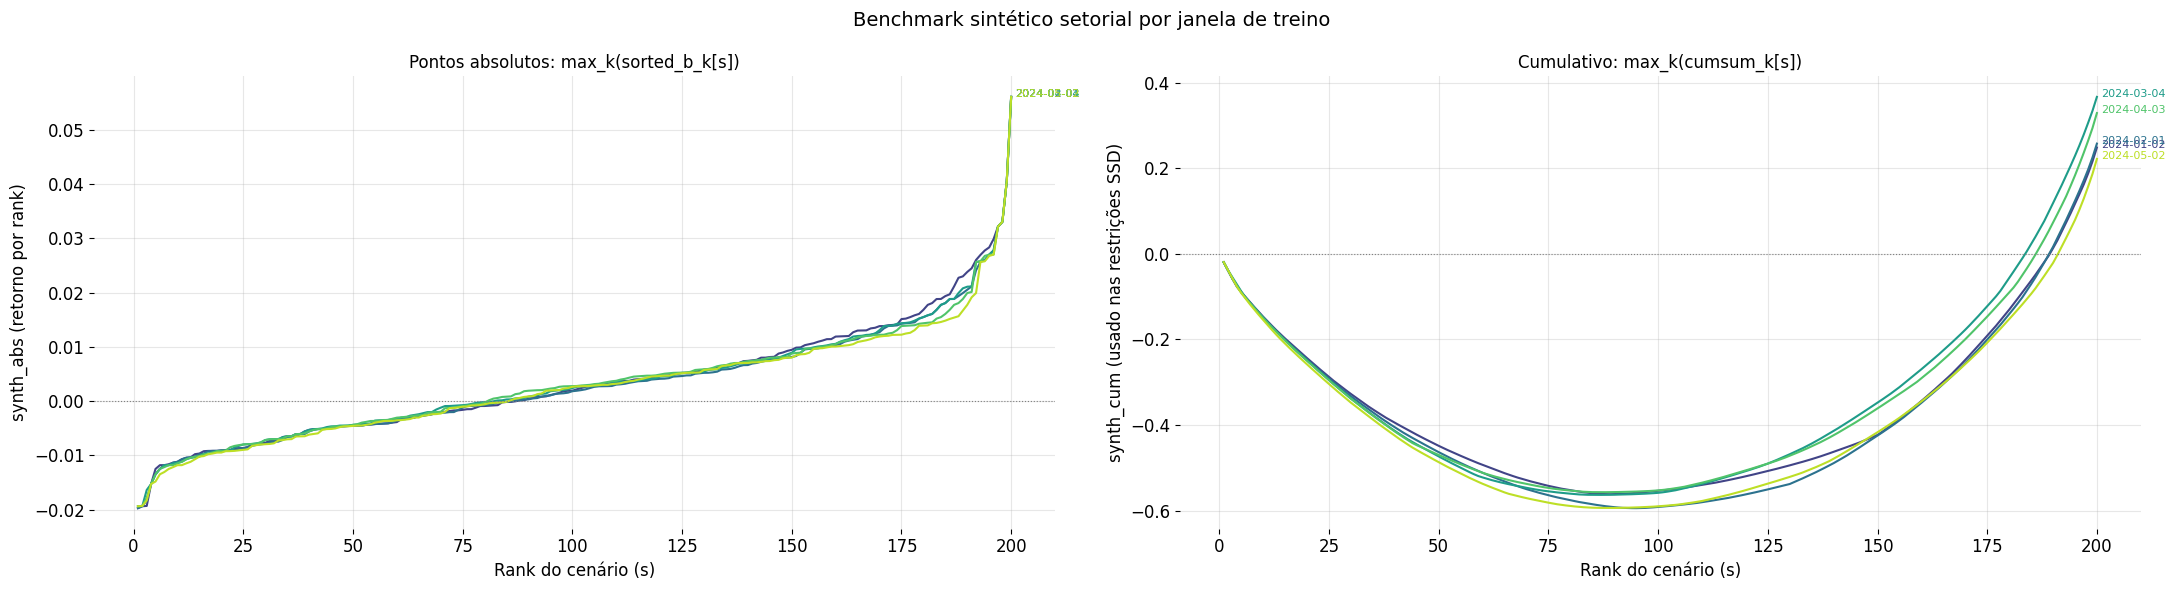

In [9]:
# Per-window synthetic benchmark curves
synth_files = sorted(SECTORS_DIR_OUT.glob('synthetic_bench-*.csv'))
print(f'{len(synth_files)} janelas de treino encontradas\n')

if synth_files:
    fig, axes = plt.subplots(1, 2, figsize=(22, 6))
    fig.patch.set_facecolor('white')
    colors_w = cm.viridis(np.linspace(0.2, 0.9, len(synth_files)))

    for color, f in zip(colors_w, synth_files):
        df   = pd.read_csv(f)
        date = f.stem.replace('synthetic_bench-', '')
        axes[0].plot(df['rank'], df['synth_abs'], linewidth=1.5, color=color)
        axes[1].plot(df['rank'], df['synth_tau'], linewidth=1.5, color=color)
        axes[0].annotate(date, xy=(df['rank'].iloc[-1], df['synth_abs'].iloc[-1]),
                         xytext=(3,0), textcoords='offset points', fontsize=8, color=color)
        axes[1].annotate(date, xy=(df['rank'].iloc[-1], df['synth_tau'].iloc[-1]),
                         xytext=(3,0), textcoords='offset points', fontsize=8, color=color)

    for ax, ttl, yl in zip(axes,
            ['Pontos por rank implícitos no envelope: diff(S·τ_synth)', 'Tail expectation: max_k(Tail_{s/S_k}(I_k))'],
            ['synth_abs (retorno por rank)', 'synth_tau (usado nas restrições SSD)']):
        ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
        ax.set_title(ttl, fontsize=12); ax.set_xlabel('Rank do cenário (s)')
        ax.set_ylabel(yl)
        for sp in ax.spines.values(): sp.set_visible(False)

    plt.suptitle('Benchmark sintético setorial por janela de treino', fontsize=14)
    plt.tight_layout()
    plt.savefig(SECTORS_DIR_OUT / 'synthetic_bench_windows.pdf', bbox_inches='tight')
    plt.show()
else:
    print('[AVISO]: Nenhum arquivo synthetic_bench-*.csv encontrado. '
          'Execute tafmSSD-sectors.py primeiro.')


**Synthetic Benchmark por janela de treino (curvas absolutas e cumulativas)**

O painel esquerdo (`synth_abs`) mostra o retorno por rank implícito no envelope sintético (primeira diferença do cumulativo $S\cdot\tau_{\text{synth}}$) — do pior ao melhor cenário dentro da janela de treino. O painel direito (`synth_tau`) exibe a esperança incondicional de cauda, $\tau_{\text{synth}}[s] = \max_k(\mathrm{Tail}_{s/S^k})$, que entra diretamente nas restrições SSD do LP. Curvas muito próximas entre janelas distintas (cores do viridis sobrepostas) indicam que o Synthetic Benchmark é estável ao longo do tempo, o que favorece consistência nas restrições a cada rebalanceamento. O ponto de cruzamento zero em `synth_abs` delimita a fronteira entre cenários de perda e ganho: um cruzamento tardio (muitos ranks negativos) significa que os piores cenários do Synthetic Benchmark concentram perdas significativas, impondo restrições muito exigentes nas caudas negativas. A inclinação de `synth_tau` na região dos piores ranks determina a "dureza" das restrições SSD mais difíceis de satisfazer — janelas com inclinação íngreme forçam o portfólio a manter maior reserva de retornos cumulativos nos cenários de downside. Divergência entre janelas indica períodos de mercado qualitativamente distintos que geraram diferentes estruturas de restrição ao solver.


---
## 5. Constraint tightness — τ_k por setor por janela de treino

τ_k[s] = Tail_{s/S_k}(I_k) = (1/S_k)·cumsum(sorted(sector_k_returns))[s] para cada setor k — a esperança incondicional dos s piores retornos.
τ_synth[s] = max_k(τ_k[s]) — restrição binding em cada rank s.


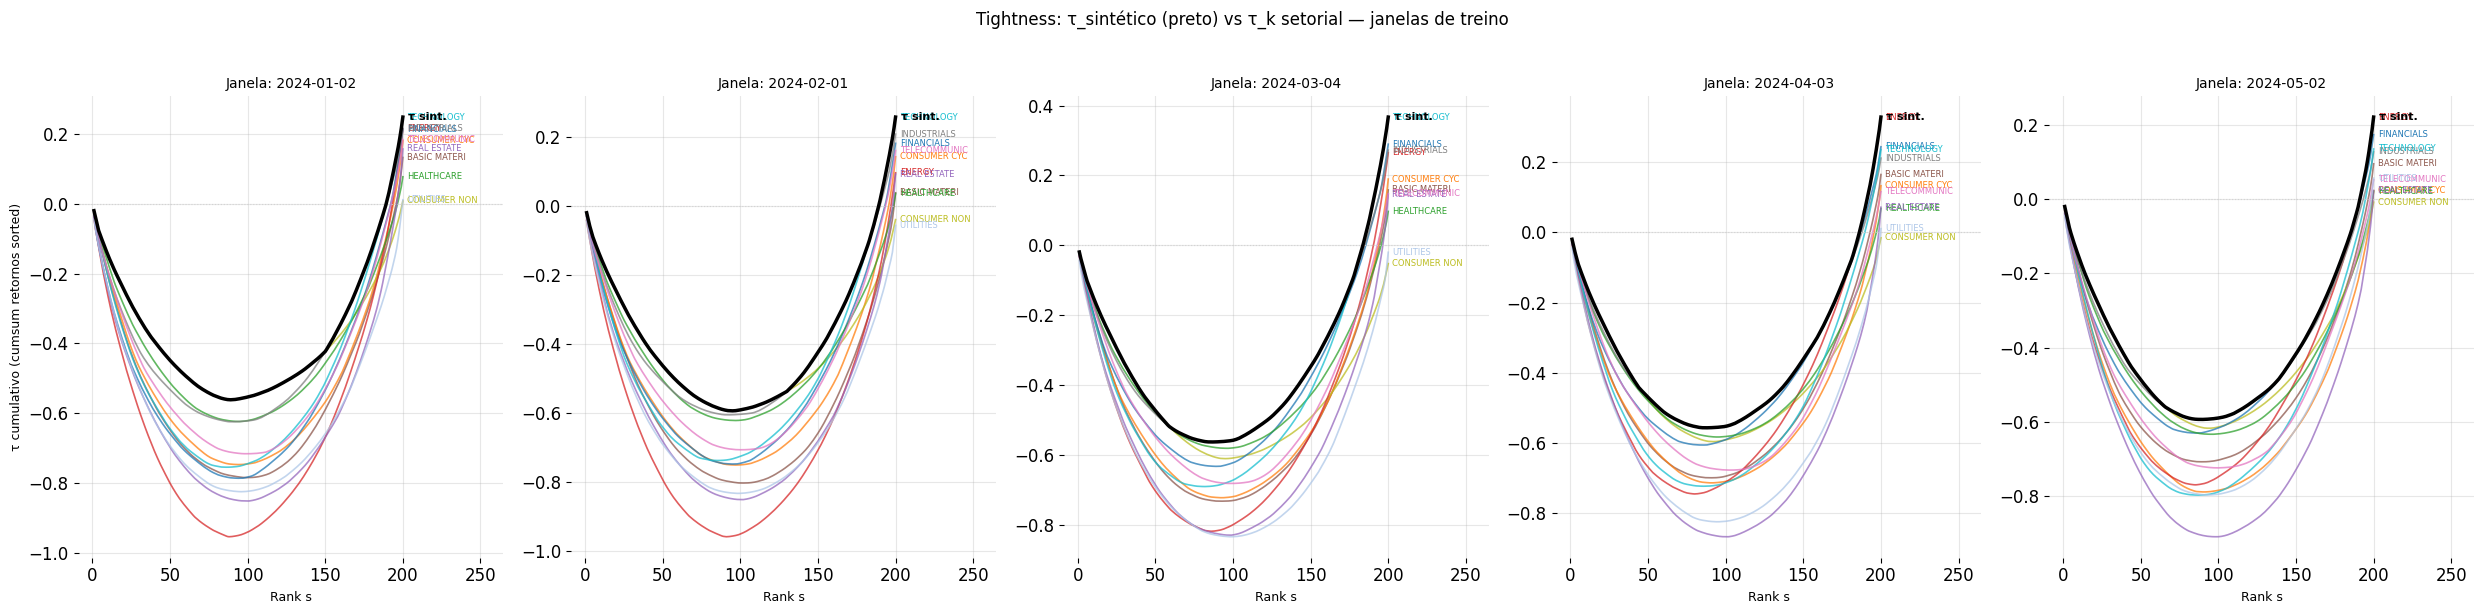

In [10]:
TRAIN_DAYS  = 200

synth_files = sorted(SECTORS_DIR_OUT.glob('synthetic_bench-*.csv'))
n_windows   = len(synth_files)

tau_by_window = {}

if n_windows > 0:
    fig, axes = plt.subplots(1, n_windows, figsize=(5 * n_windows, 6), sharey=False)
    if n_windows == 1:
        axes = [axes]
    fig.patch.set_facecolor('white')

    for ax, f in zip(axes, synth_files):
        date_str = f.stem.replace('synthetic_bench-', '')
        date     = pd.Timestamp(date_str)
        ax.set_facecolor('white')

        loc     = sector_returns.index.get_loc(date)
        train_b = sector_returns.iloc[max(0, loc - TRAIN_DAYS + 1): loc + 1]
        S       = len(train_b)
        ranks   = np.arange(1, S + 1)

        tau_matrix = {}
        for s in AVAILABLE_SECTORS:
            col = train_b[s].dropna()
            if len(col) > 0:
                tau_matrix[s] = np.cumsum(np.sort(col.values)) / len(col)
            else:
                tau_matrix[s] = np.zeros(S)

        tau_by_window[date_str] = tau_matrix
        synth_df = pd.read_csv(f)

        for sector, tau in tau_matrix.items():
            color = SECTOR_PALETTE[sector]
            ax.plot(ranks[:len(tau)], tau, linewidth=1.2, color=color, alpha=0.75)
            ax.annotate(sector.replace('_', ' ')[:12], xy=(ranks[len(tau)-1], tau[-1]),
                        xytext=(3, 0), textcoords='offset points',
                        va='center', fontsize=6, color=color)

        ax.plot(synth_df['rank'], synth_df['synth_tau'],
                linewidth=2.5, color='black', zorder=5)
        ax.annotate('τ sint.', xy=(synth_df['rank'].iloc[-1], synth_df['synth_tau'].iloc[-1]),
                    xytext=(4, 0), textcoords='offset points',
                    va='center', fontsize=8, color='black', fontweight='bold')

        ax.axhline(0, color='lightgray', linewidth=0.8, linestyle=':')
        x_min, x_max = ax.get_xlim()
        ax.set_xlim(x_min, x_max + (x_max - x_min) * 0.25)
        ax.set_title(f'Janela: {date_str}', fontsize=10)
        ax.set_xlabel('Rank s', fontsize=9)
        for sp in ax.spines.values(): sp.set_visible(False)

    axes[0].set_ylabel('τ (tail expectation: cumsum/S_k dos retornos sorted)', fontsize=9)
    fig.suptitle(
        'Tightness: τ_sintético (preto) vs τ_k setorial — janelas de treino',
        fontsize=12, y=1.02,
    )
    plt.tight_layout()
    plt.savefig(SECTORS_DIR_OUT / 'constraint_tightness.pdf', bbox_inches='tight')
    plt.show()
else:
    print('[AVISO]: Execute tafmSSD-sectors.py primeiro.')


**Constraint tightness: τ_k por setor por janela de treino**

Para cada janela de treino, τ_k[s] = Tail_{s/S_k}(I_k) é a esperança incondicional dos s piores retornos do setor k ((1/S_k)·Σ dos retornos ordenados), e τ_synth[s] = max_k(τ_k[s]) é a envolvente superior que determina as restrições efetivas do LP. Um gap estreito entre τ_synth e um setor específico indica que aquele setor foi o binding constraint para os ranks correspondentes: pequenas variações em seus retornos mudariam o nível da restrição. A variação do gap ao longo dos ranks revela se um dado setor é binding apenas nas caudas (piores cenários) ou ao longo de toda a distribuição — informação relevante para entender onde o modelo concentrou "esforço" de otimização. τ_synth assume inevitavelmente valores negativos nos primeiros ranks (média dos piores retornos), mas a magnitude dessa negatividade importa: τ_synth muito negativo nas caudas torna as restrições SSD dos piores cenários quase intransponíveis sem sacrificar os ranks médios. Variações abruptas de τ_synth entre janelas consecutivas sinalizam instabilidade nas restrições, o que pode traduzir-se em turnover elevado no portfólio a cada rebalanceamento.


---
## 6. Setor dominante por rank — qual setor é binding em cada rank s?

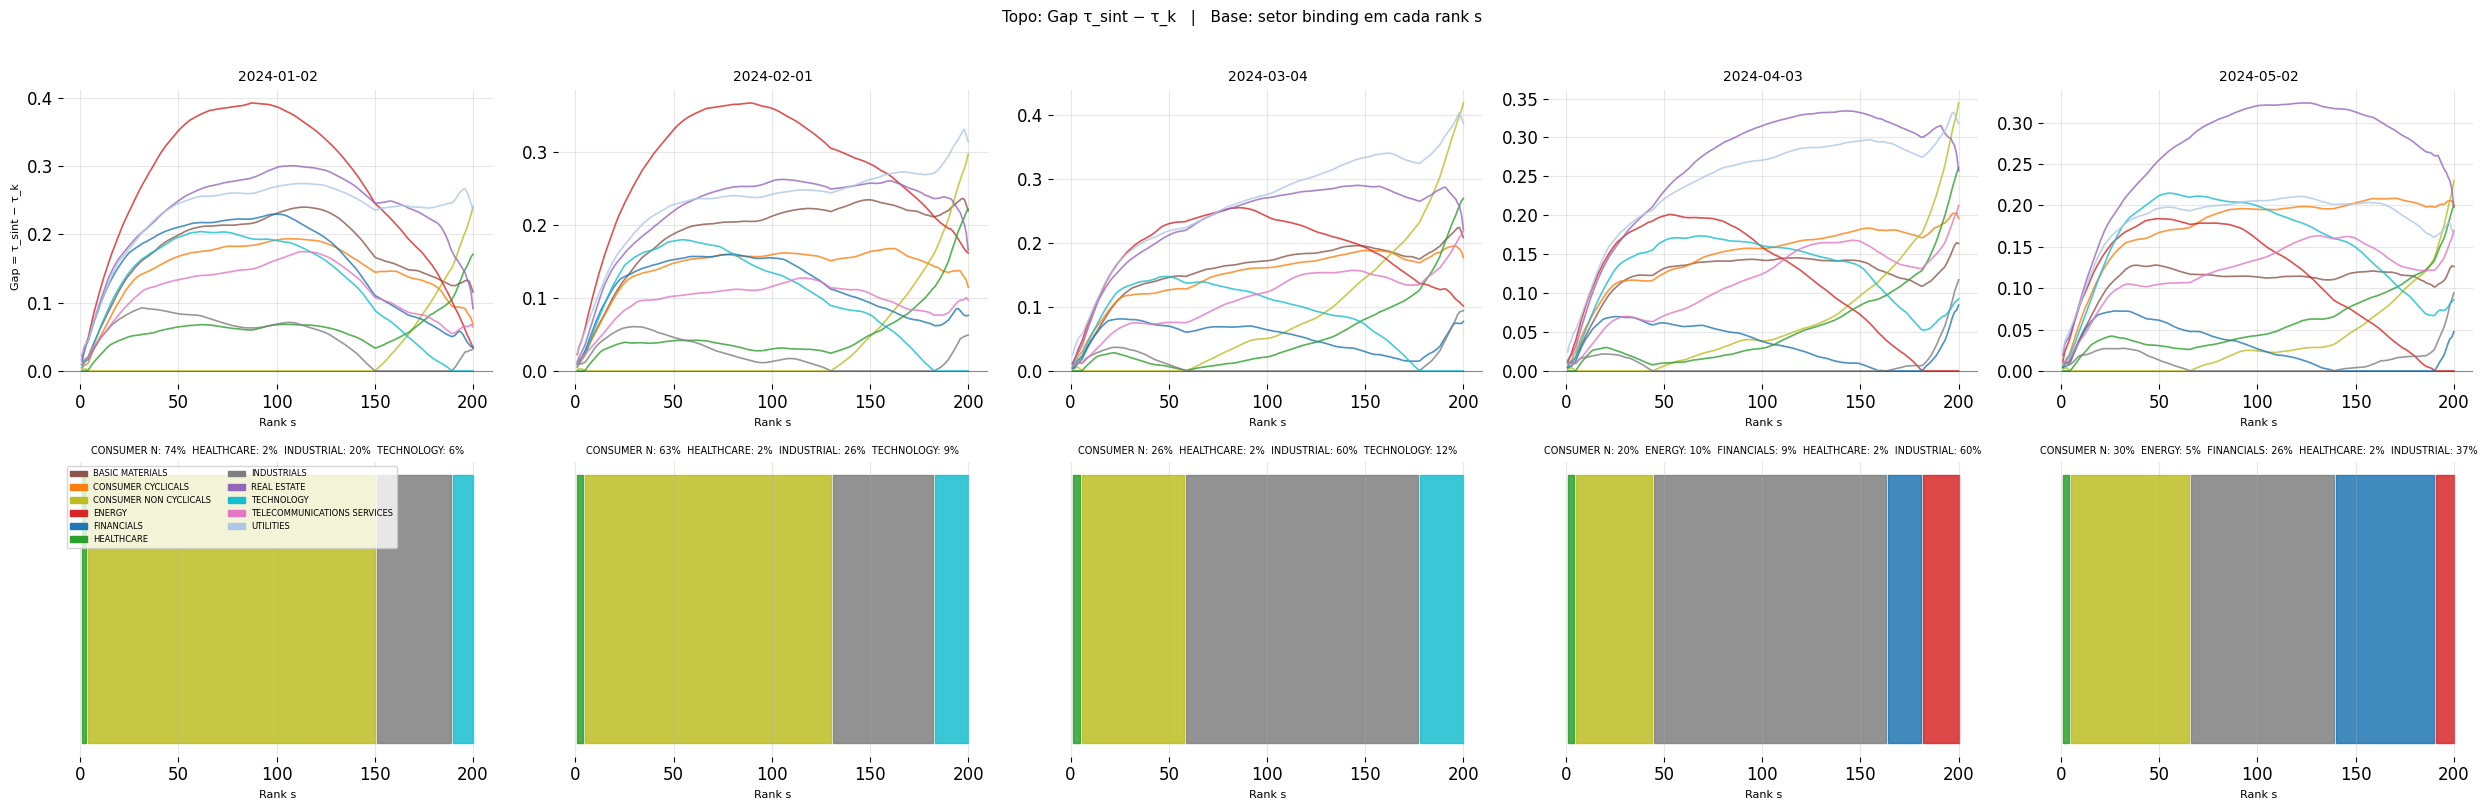

In [11]:
if tau_by_window:
    fig, axes = plt.subplots(2, n_windows, figsize=(5 * n_windows, 8))
    if n_windows == 1:
        axes = axes.reshape(2, 1)
    fig.patch.set_facecolor('white')

    for col_i, (f, date_str) in enumerate(
            [(f, f.stem.replace('synthetic_bench-', '')) for f in synth_files]):

        tau_matrix = tau_by_window[date_str]
        lens = [len(v) for v in tau_matrix.values()]
        S    = min(lens)
        stacked  = np.column_stack([tau_matrix[s][:S] for s in AVAILABLE_SECTORS])
        dom_idx  = np.argmax(stacked, axis=1)
        ranks    = np.arange(1, S + 1)
        synth_v  = stacked[np.arange(S), dom_idx]

        # Top: gap per sector
        ax_top = axes[0, col_i]; ax_top.set_facecolor('white')
        for i, sector in enumerate(AVAILABLE_SECTORS):
            gap = synth_v - stacked[:, i]
            ax_top.plot(ranks, gap, linewidth=1.2, color=SECTOR_PALETTE[sector], alpha=0.8)
        ax_top.axhline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.4)
        ax_top.set_title(date_str, fontsize=10)
        ax_top.set_xlabel('Rank s', fontsize=8)
        if col_i == 0:
            ax_top.set_ylabel('Gap = τ_sint − τ_k', fontsize=8)
        for sp in ax_top.spines.values(): sp.set_visible(False)

        # Bottom: color strip
        ax_bot = axes[1, col_i]; ax_bot.set_facecolor('white')
        for i, sector in enumerate(AVAILABLE_SECTORS):
            mask = (dom_idx == i)
            ax_bot.fill_between(ranks, 0, 1, where=mask,
                                color=SECTOR_PALETTE[sector], alpha=0.85)
        cnt     = Counter(int(j) for j in dom_idx)
        summary = '  '.join(
            f'{AVAILABLE_SECTORS[k].replace("_"," ")[:10]}: {cnt[k]/S*100:.0f}%'
            for k in sorted(cnt) if cnt[k] > 0
        )
        ax_bot.set_title(summary, fontsize=7)
        ax_bot.set_xlabel('Rank s', fontsize=8)
        ax_bot.set_yticks([])
        for sp in ax_bot.spines.values(): sp.set_visible(False)

    # Legend on first bottom panel
    from matplotlib.patches import Patch
    legend_patches = [Patch(color=SECTOR_PALETTE[s], label=s.replace('_', ' '))
                      for s in AVAILABLE_SECTORS]
    axes[1, 0].legend(handles=legend_patches, fontsize=6, loc='upper left', ncol=2)

    fig.suptitle(
        'Topo: Gap τ_sint − τ_k   |   Base: setor binding em cada rank s',
        fontsize=11, y=1.01,
    )
    plt.tight_layout()
    plt.savefig(SECTORS_DIR_OUT / 'constraint_dominance_by_rank.pdf', bbox_inches='tight')
    plt.show()


**Setor dominante por rank s (qual setor é binding em cada rank)**

O painel superior (gap τ_synth − τ_k) e o painel inferior (setor binding em cada rank) revelam a estrutura interna do Synthetic Benchmark em cada janela de treino. Quando o painel de cores inferior exibe um único setor dominando a maioria dos ranks (blocos largos de uma única cor), o Synthetic Benchmark é efetivamente uni-setorial para aquela janela — equivalendo, na prática, a otimizar contra aquele setor isolado. Alta fragmentação indica um Synthetic Benchmark genuinamente multi-setorial: o portfólio deve simultaneamente se defender dos piores cenários de um setor e dos melhores cenários de outro, tornando o problema de otimização mais complexo. Quando múltiplos setores competem pela posição binding no mesmo rank (gap pequeno em vários setores simultaneamente), o Synthetic Benchmark é especialmente "difícil" naquela região da distribuição. Por fim, a variação do setor dominante entre janelas consecutivas explica mudanças abruptas na composição do portfólio: ao rebalancear, o solver está reagindo a uma estrutura de restrições qualitativamente diferente.


---
## 7. Visão geral — portfólio vs setores

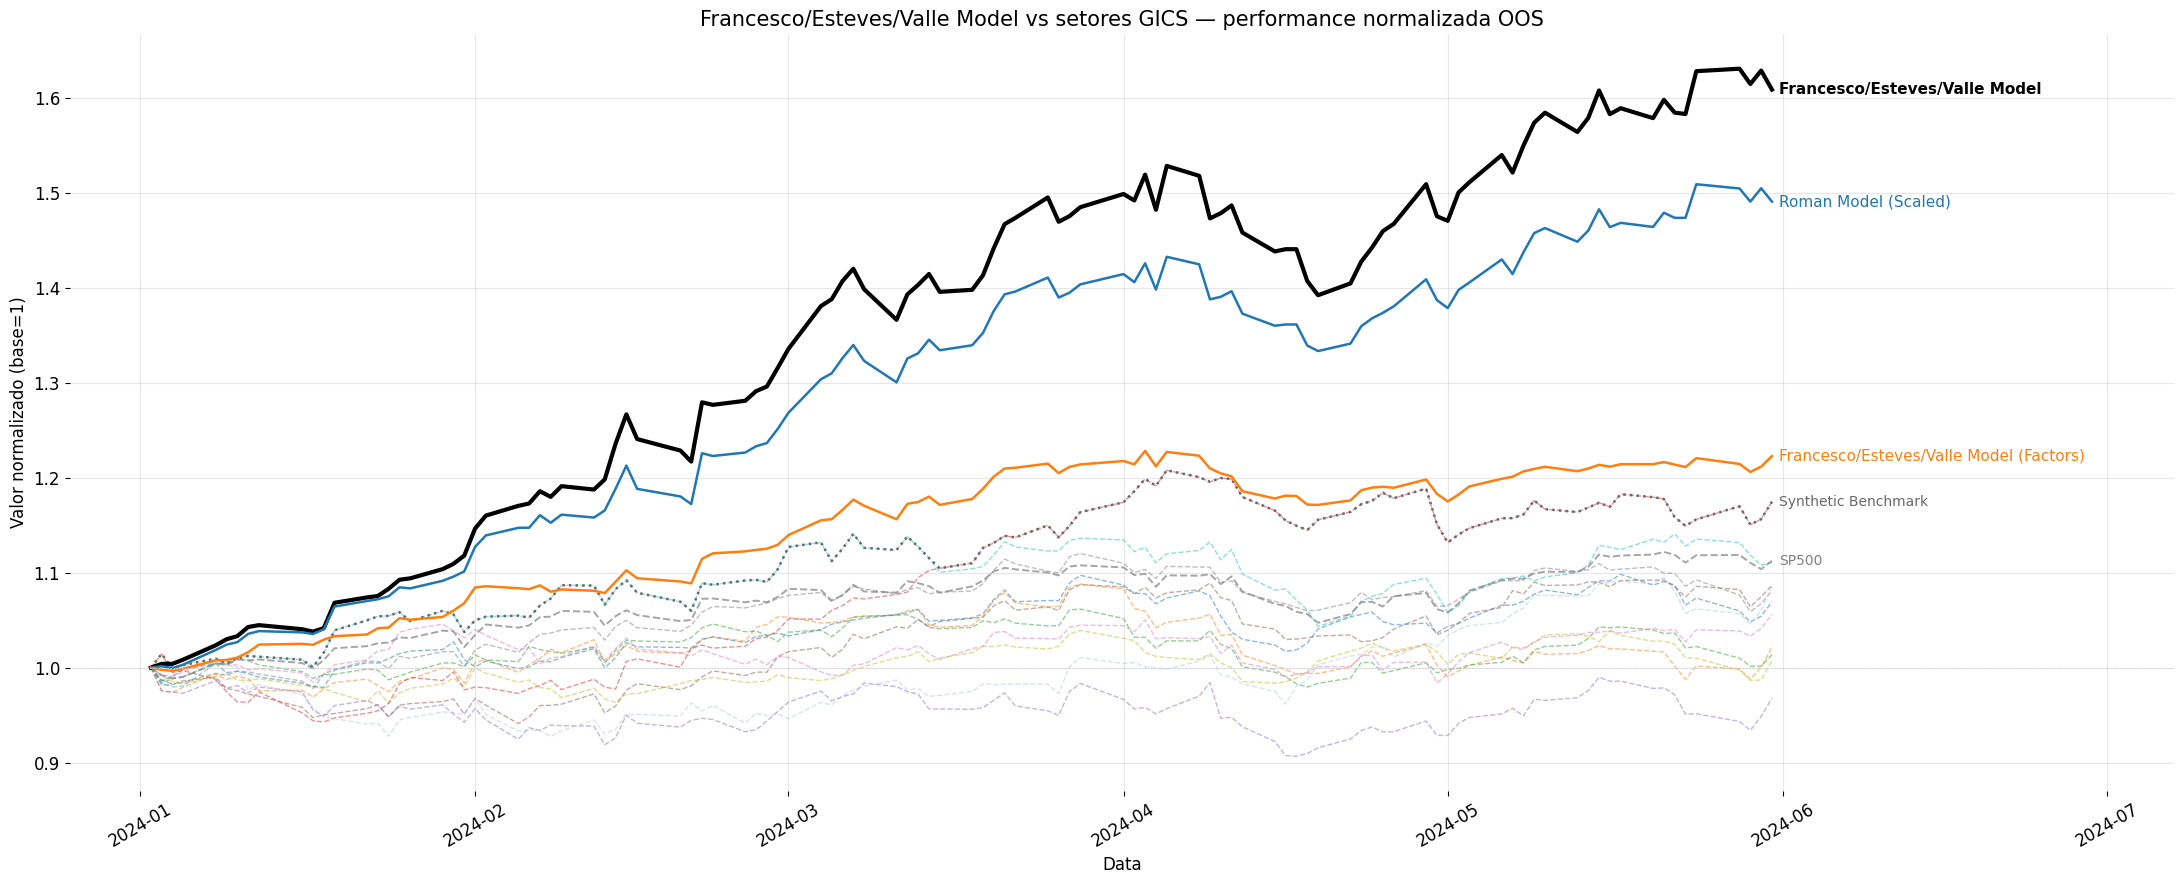

In [12]:
MODEL_COLORS = {
    'Francesco/Esteves/Valle Model': '#000000',
    'Roman Model (Scaled)':          '#1f77b4',
    'Francesco/Esteves/Valle Model (Factors)': '#ff7f0e',
}

fig, ax = plt.subplots(figsize=(22, 9))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')

# Sector benchmarks (background, dashed)
for sector in AVAILABLE_SECTORS:
    norm  = sector_oos[sector]['norm']
    color = SECTOR_PALETTE[sector]
    ax.plot(norm.index, norm.values, linewidth=1.0, linestyle='--', color=color, alpha=0.5)

# Synthetic benchmark
ax.plot(synth_oos.index, synth_oos.values, linewidth=1.8, color='dimgray', linestyle=':')
ax.annotate('Synthetic Benchmark', xy=(synth_oos.index[-1], synth_oos.iloc[-1]),
            xytext=(5, 0), textcoords='offset points', va='center',
            fontsize=10, color='dimgray')

# Portfolio models (foreground, solid)
for label, series in models.items():
    color = MODEL_COLORS.get(label, '#999999')
    lw    = 3.0 if label == 'Francesco/Esteves/Valle Model' else 1.8
    ax.plot(idx, series.values, linewidth=lw, color=color, linestyle='-')
    ax.annotate(label, xy=(idx[-1], series.iloc[-1]),
                xytext=(5, 0), textcoords='offset points', va='center',
                fontsize=11, color=color,
                fontweight='bold' if label == 'Francesco/Esteves/Valle Model' else 'normal')

# SP500
ax.plot(sp500_norm.index, sp500_norm.values, linewidth=1.4, color='gray', linestyle='--', alpha=0.7)
ax.annotate('SP500', xy=(sp500_norm.index[-1], sp500_norm.iloc[-1]),
            xytext=(5, 0), textcoords='offset points', va='center',
            fontsize=10, color='gray')

ax.axhline(1.0, color='lightgray', linewidth=0.8, linestyle=':')
x_min, x_max = ax.get_xlim()
ax.set_xlim(x_min, x_max + (x_max - x_min) * 0.18)
ax.set_title('Francesco/Esteves/Valle Model vs setores GICS — performance normalizada OOS', fontsize=15)
ax.set_xlabel('Data'); ax.set_ylabel('Valor normalizado (base=1)')
ax.tick_params(axis='x', rotation=30)
for sp in ax.spines.values(): sp.set_visible(False)
plt.tight_layout()
plt.savefig(SECTORS_DIR_OUT / 'all_models_comparison.pdf', bbox_inches='tight')
plt.show()


**Visão geral: portfólio vs setores GICS**

Este gráfico consolida a performance normalizada do Francesco/Esteves/Valle Model (linha preta espessa) em relação a todos os 11 setores e ao Synthetic Benchmark, sendo a visualização mais importante do experimento. A posição relativa do portfólio em relação ao conjunto de setores é a evidência primária da validade OOS do modelo: uma trajetória consistentemente acima da mediana setorial confirma que a dominância SSD in-sample transferiu-se para o período de teste. A distância entre o portfólio e o Synthetic Benchmark (teto teórico) mede o custo combinado de diversificação e satisfação simultânea de todas as restrições SSD — um gap inevitável na abordagem multi-benchmark. A comparação com o Roman Model (Scaled) e o FEV Model (Factors) permite isolar o efeito da escolha de benchmark: diferenças significativas entre os três portfólios indicam que o tipo de benchmark altera substancialmente o processo de otimização e os pesos resultantes, enquanto trajetórias similares sugerem robustez da abordagem SSD independentemente do benchmark escolhido.


---
## 8. Drawdown comparativo

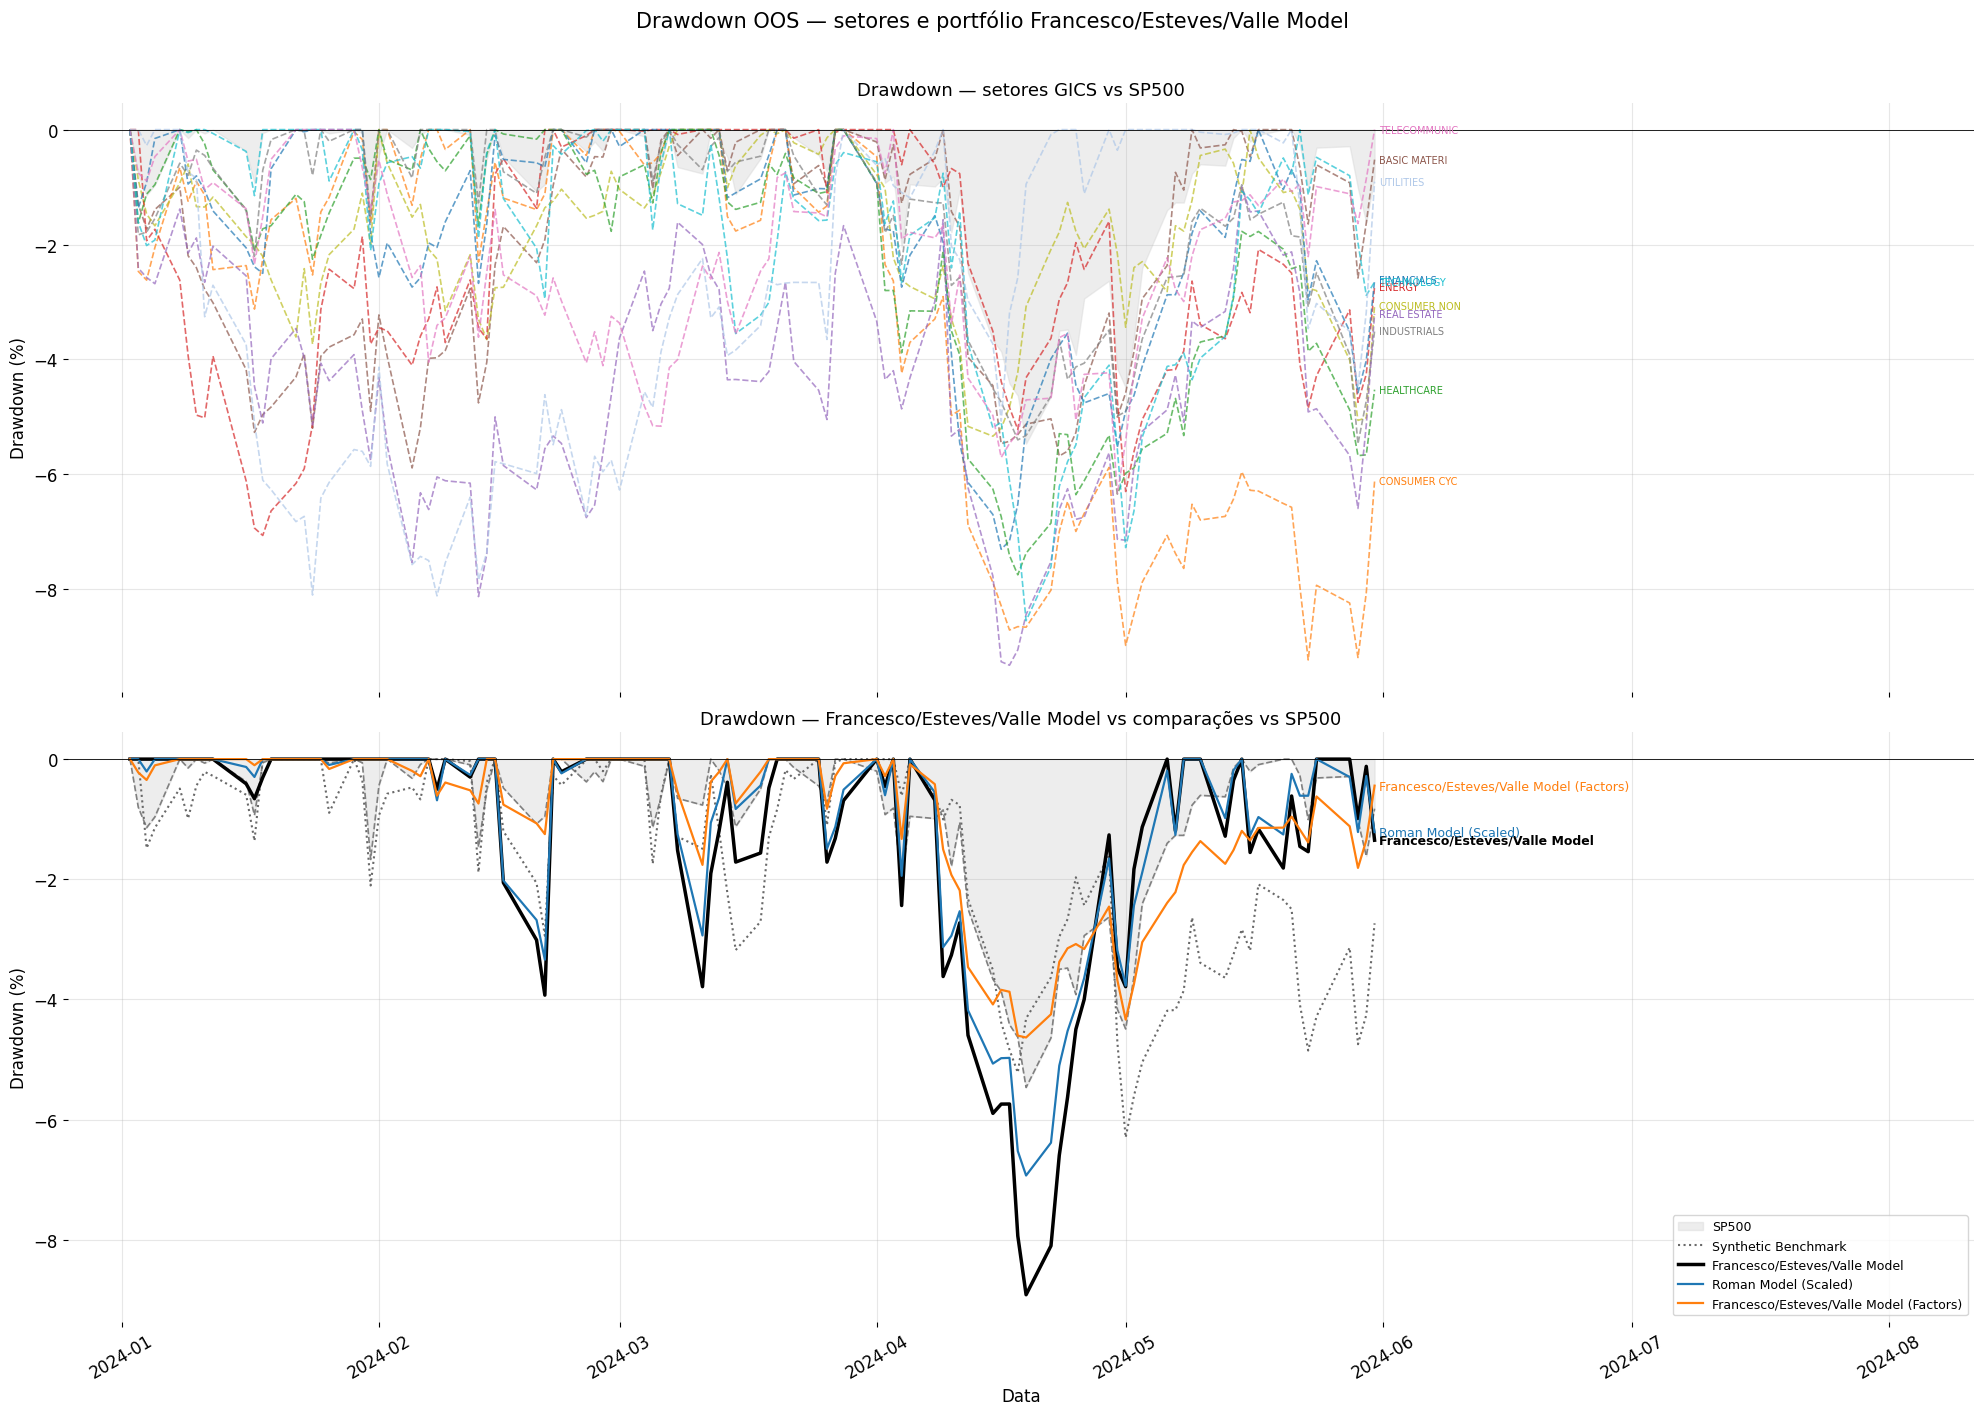

In [13]:
def compute_drawdown(series):
    roll_max = series.expanding().max()
    return (series / roll_max - 1) * 100

sp500_dd = compute_drawdown(sp500_norm)

fig, axes = plt.subplots(2, 1, figsize=(20, 14), sharex=True)
fig.patch.set_facecolor('white')

# Panel 1: sector benchmarks drawdown
ax1 = axes[0]; ax1.set_facecolor('white')
ax1.fill_between(idx, sp500_dd.values, 0, color='lightgray', alpha=0.4, label='SP500')
for sector in AVAILABLE_SECTORS:
    norm  = sector_oos[sector]['norm'].reindex(idx)
    dd    = compute_drawdown(norm)
    ax1.plot(idx, dd.values, linewidth=1.2, linestyle='--',
             color=SECTOR_PALETTE[sector], alpha=0.7)
    ax1.annotate(sector.replace('_', ' ')[:12], xy=(idx[-1], dd.iloc[-1]),
                 xytext=(3, 0), textcoords='offset points', va='center',
                 fontsize=7, color=SECTOR_PALETTE[sector])
ax1.axhline(0, color='black', linewidth=0.6)
ax1.set_title('Drawdown — setores GICS vs SP500', fontsize=13)
ax1.set_ylabel('Drawdown (%)')
x_min, x_max = ax1.get_xlim()
ax1.set_xlim(x_min, x_max + (x_max - x_min) * 0.18)
for sp in ax1.spines.values(): sp.set_visible(False)

# Panel 2: portfolio drawdown
ax2 = axes[1]; ax2.set_facecolor('white')
ax2.fill_between(idx, sp500_dd.values, 0, color='lightgray', alpha=0.4, label='SP500')
ax2.plot(idx, sp500_dd.values, color='gray', linewidth=1.2, linestyle='--')

synth_dd = compute_drawdown(synth_oos)
ax2.plot(idx, synth_dd.values, linewidth=1.5, linestyle=':', color='dimgray', label='Synthetic Benchmark')

for label, series in models.items():
    color = MODEL_COLORS.get(label, '#999999')
    lw    = 2.5 if label == 'Francesco/Esteves/Valle Model' else 1.6
    dd    = compute_drawdown(series.reindex(idx))
    ax2.plot(idx, dd.values, linewidth=lw, color=color, label=label)
    ax2.annotate(label, xy=(idx[-1], dd.iloc[-1]), xytext=(3, 0),
                 textcoords='offset points', va='center', fontsize=9, color=color,
                 fontweight='bold' if label == 'Francesco/Esteves/Valle Model' else 'normal')

ax2.axhline(0, color='black', linewidth=0.6)
ax2.set_title('Drawdown — Francesco/Esteves/Valle Model vs comparações vs SP500', fontsize=13)
ax2.set_ylabel('Drawdown (%)'); ax2.set_xlabel('Data')
ax2.legend(fontsize=9, loc='lower right')
ax2.tick_params(axis='x', rotation=30)
x_min, x_max = ax2.get_xlim()
ax2.set_xlim(x_min, x_max + (x_max - x_min) * 0.18)
for sp in ax2.spines.values(): sp.set_visible(False)

plt.suptitle('Drawdown OOS — setores e portfólio Francesco/Esteves/Valle Model', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(SECTORS_DIR_OUT / 'drawdown_comparison.pdf', bbox_inches='tight')
plt.show()


**Drawdown comparativo**

O painel superior mostra os drawdowns dos 11 setores individualmente, fornecendo o contexto de downside do universo de benchmarks. O painel inferior compara os modelos entre si e com o Synthetic Benchmark. Um portfólio otimizado via SSD deve apresentar drawdowns menores do que a maioria dos setores individualmente: a exigência de dominância SSD in-sample força diversificação que tende a suavizar quedas, embora sem garantia explícita de drawdown máximo (este não é o objetivo da formulação). A velocidade de recuperação após um drawdown é tão informativa quanto a profundidade: recuperações rápidas indicam portfólio bem posicionado para capturar o upside subsequente. A correlação de drawdowns entre os modelos é particularmente relevante — ocorrência simultânea de máximos de drawdown no Francesco/Esteves/Valle Model e no Roman Model sugere que o evento foi sistêmico (independente do benchmark), enquanto divergência entre os drawdowns dos dois modelos indica que a escolha de benchmark setorial vs SP500 faz diferença concreta no comportamento de downside OOS.


---
## 9. Métricas OOS — tabela completa

In [14]:
rows = {}
rows['SP500']     = compute_metrics(sp500_norm, benchmark=sp500_norm, rf_annual=RISK_FREE)
rows['Synthetic Benchmark'] = compute_metrics(synth_oos,  benchmark=sp500_norm, rf_annual=RISK_FREE)

for label, series in models.items():
    rows[label] = compute_metrics(series.reindex(idx), benchmark=sp500_norm, rf_annual=RISK_FREE)

for sector in AVAILABLE_SECTORS:
    norm = sector_oos[sector]['norm'].reindex(idx)
    rows[sector.replace('_', ' ')] = compute_metrics(norm, benchmark=sp500_norm, rf_annual=RISK_FREE)

metrics_df = pd.DataFrame(rows).T
display(
    metrics_df.style
    .background_gradient(cmap='RdYlGn',
        subset=['Final value', 'CAGR (%)', 'Sharpe Ratio', 'Sortino Ratio'])
    .background_gradient(cmap='RdYlGn_r',
        subset=['Volatility (%)', 'Daily CVaR 5% (%)', 'Max Drawdown (%)'])
    .format(precision=4, na_rep='--')
)


,Final value,CAGR (%),Volatility (%),Daily CVaR 5% (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Portfolio beta
SP500,1.1127,29.5400,11.3400,1.4070,1.9096,3.5279,-5.4600,1.0000
Synthetic Benchmark,1.1750,47.8000,16.4800,1.9740,2.1585,4.1251,-6.3000,1.0160
Francesco/Esteves/Valle Model,1.6092,216.6700,22.1400,2.3860,5.1060,17.3129,-8.9100,1.1739
Roman Model (Scaled),1.4911,163.2900,18.2900,1.9300,5.1260,15.2550,-6.9300,1.0043
Francesco/Esteves/Valle Model (Factors),1.2230,62.8800,10.2900,1.1700,4.3224,9.3841,-4.6300,0.6071
BASIC MATERIALS,1.0867,22.3300,14.4600,1.9300,1.1288,1.8106,-5.8900,0.7860
CONSUMER CYCLICALS,1.0215,5.3000,15.3700,2.1660,0.0949,0.0273,-9.2300,1.0009
CONSUMER NON CYCLICALS,1.0073,1.7900,11.7300,1.3310,-0.2070,-0.4966,-5.3400,0.3211
ENERGY,1.1750,47.8000,15.8100,2.0990,2.2436,3.8203,-7.0600,0.5442
FINANCIALS,1.0696,17.7000,13.0200,1.7820,0.9421,1.3990,-7.3000,0.6215


**Métricas OOS (tabela completa)**

A tabela consolida as principais métricas de performance para todos os modelos, benchmarks e setores no período OOS. O gradiente de cor (vermelho → amarelo → verde) facilita a identificação de outliers. O Sharpe Ratio e o Sortino Ratio são as métricas de risco ajustado mais relevantes: a dominância SSD in-sample deveria implicar Sharpe ≥ benchmark, mas isso é garantido apenas em distribuição e apenas in-sample — o OOS é o teste real. A diferença entre Sharpe e Sortino (que penaliza apenas downside) revela se o portfólio tem assimetria de risco: um Sortino muito superior ao Sharpe confirma downside menor que upside, coerente com a otimização SSD. O Daily CVaR 5% mede a perda esperada nos 5% piores dias — valores menos negativos confirmam proteção de downside. Um portfólio com menor CAGR que o Synthetic Benchmark pode ainda ser preferível se apresentar volatilidade significativamente menor; o Sharpe captura esse trade-off diretamente. O beta contra o SP500 proxia o grau de correlação sistêmica: valores abaixo de 1 são esperados em portfólios SSD-otimizados, que tendem a reduzir exposição ao mercado em favor de diversificação.


---
## 10. Dominância SSD

Francesco/Esteves/Valle Model vs Synthetic Benchmark: min(SSD) = -0.044205  ✗ VIOLA 
Roman Model (Scaled) vs SP500: min(SSD) = -0.074537  ✗ VIOLA 
Francesco/Esteves/Valle Model (Factors) vs SP500: min(SSD) = +0.002830  ✓ DOMINA
[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd-sectors/ssd_home_dominance.pdf


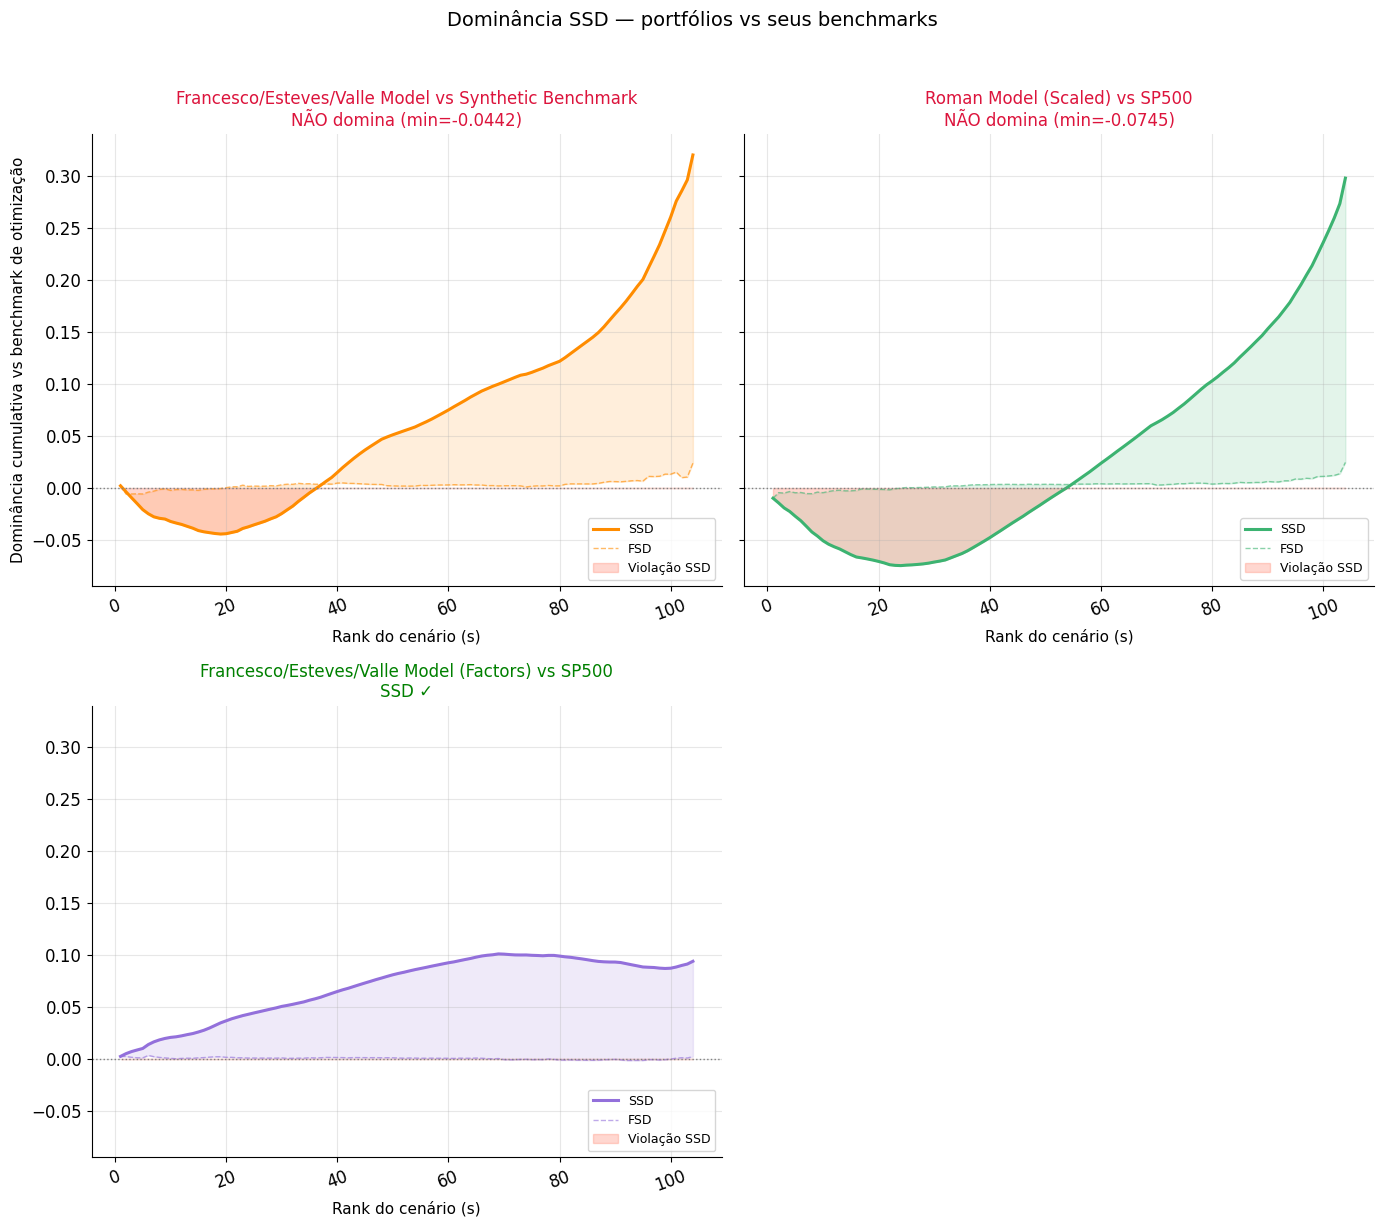

In [15]:
# Home dominance: Francesco/Esteves/Valle Model vs synthetic sector benchmark
if 'Francesco/Esteves/Valle Model' in models:
    port_series = models['Francesco/Esteves/Valle Model'].reindex(idx)
    port_ret    = port_series.pct_change().dropna()
    synth_ret   = synth_oos.pct_change().dropna()
    common      = port_ret.index.intersection(synth_ret.index)
    s, fsd, ssd = compute_ssd_dominance(
        port_ret.loc[common].values, synth_ret.loc[common].values
    )
    tag = '✓ DOMINA' if ssd.min() >= 0 else '✗ VIOLA '
    print(f'Francesco/Esteves/Valle Model vs Synthetic Benchmark: min(SSD) = {ssd.min():+.6f}  {tag}')

    home_dom = {'Francesco/Esteves/Valle Model vs Synthetic Benchmark': (s, fsd, ssd)}

    # Also add comparison models vs SP500
    for label, series in models.items():
        if label == 'Francesco/Esteves/Valle Model':
            continue
        r_port = series.reindex(idx).pct_change().dropna()
        r_bench = sp500_ret.reindex(r_port.index).dropna()
        common2 = r_port.index.intersection(r_bench.index)
        s2, fsd2, ssd2 = compute_ssd_dominance(
            r_port.loc[common2].values, r_bench.loc[common2].values
        )
        home_dom[f'{label} vs SP500'] = (s2, fsd2, ssd2)
        tag2 = '✓ DOMINA' if ssd2.min() >= 0 else '✗ VIOLA '
        print(f'{label} vs SP500: min(SSD) = {ssd2.min():+.6f}  {tag2}')

    plot_dominance_panels(
        home_dom, n_cols=2,
        benchmark_name='benchmark de otimização',
        title='Dominância SSD — portfólios vs seus benchmarks',
        save_path=SECTORS_DIR_OUT / 'ssd_home_dominance.pdf',
    )


**Dominância SSD: portfólios vs seus benchmarks de otimização**

Este painel verifica se cada portfólio domina SSD o seu benchmark de otimização no período OOS. A dominância SSD in-sample é garantida pelo LP — o teste aqui é a generalização. Para o Francesco/Esteves/Valle Model, a curva SSD deve estar ≥ 0 em todos os pontos para confirmar dominância OOS contra o Synthetic Benchmark setorial; violações (regiões negativas) localizam exatamente onde o benchmark superou o portfólio na distribuição acumulada. Violações nas caudas esquerdas (piores cenários) são as mais preocupantes, pois indicam que o portfólio perdeu mais do que o benchmark nos piores dias OOS — contrariando o objetivo fundamental da formulação. Violações leves (min SSD próximo de zero) são aceitáveis dado o gap temporal entre in-sample e OOS. A comparação com o Roman Model (Scaled) vs SP500 fornece o baseline: se o modelo setorial apresenta dominância OOS similar ou melhor que o Roman Model, o uso de benchmarks setoriais agrega valor sem deteriorar a propriedade de dominância.



=== Francesco/Esteves/Valle Model: dominância cruzada vs cada setor ===
  Setor                                     min(SSD)    min(FSD)  Status
  ------------------------------------------------------------------------
  BASIC_MATERIALS                          -0.058905   -0.006457  ✗ VIOLA 
  CONSUMER_CYCLICALS                       -0.027993   -0.004889  ✗ VIOLA 
  CONSUMER_NON_CYCLICALS                   -0.117114   -0.014737  ✗ VIOLA 
  ENERGY                                   -0.048470   -0.005736  ✗ VIOLA 
  FINANCIALS                               -0.079776   -0.009654  ✗ VIOLA 
  HEALTHCARE                               -0.101468   -0.010702  ✗ VIOLA 
  INDUSTRIALS                              -0.101808   -0.011252  ✗ VIOLA 
  REAL_ESTATE                              -0.000260   -0.002307  ✗ VIOLA 
  TECHNOLOGY                               -0.035799   -0.006243  ✗ VIOLA 
  TELECOMMUNICATIONS_SERVICES              -0.073409   -0.007564  ✗ VIOLA 
  UTILITIES                  

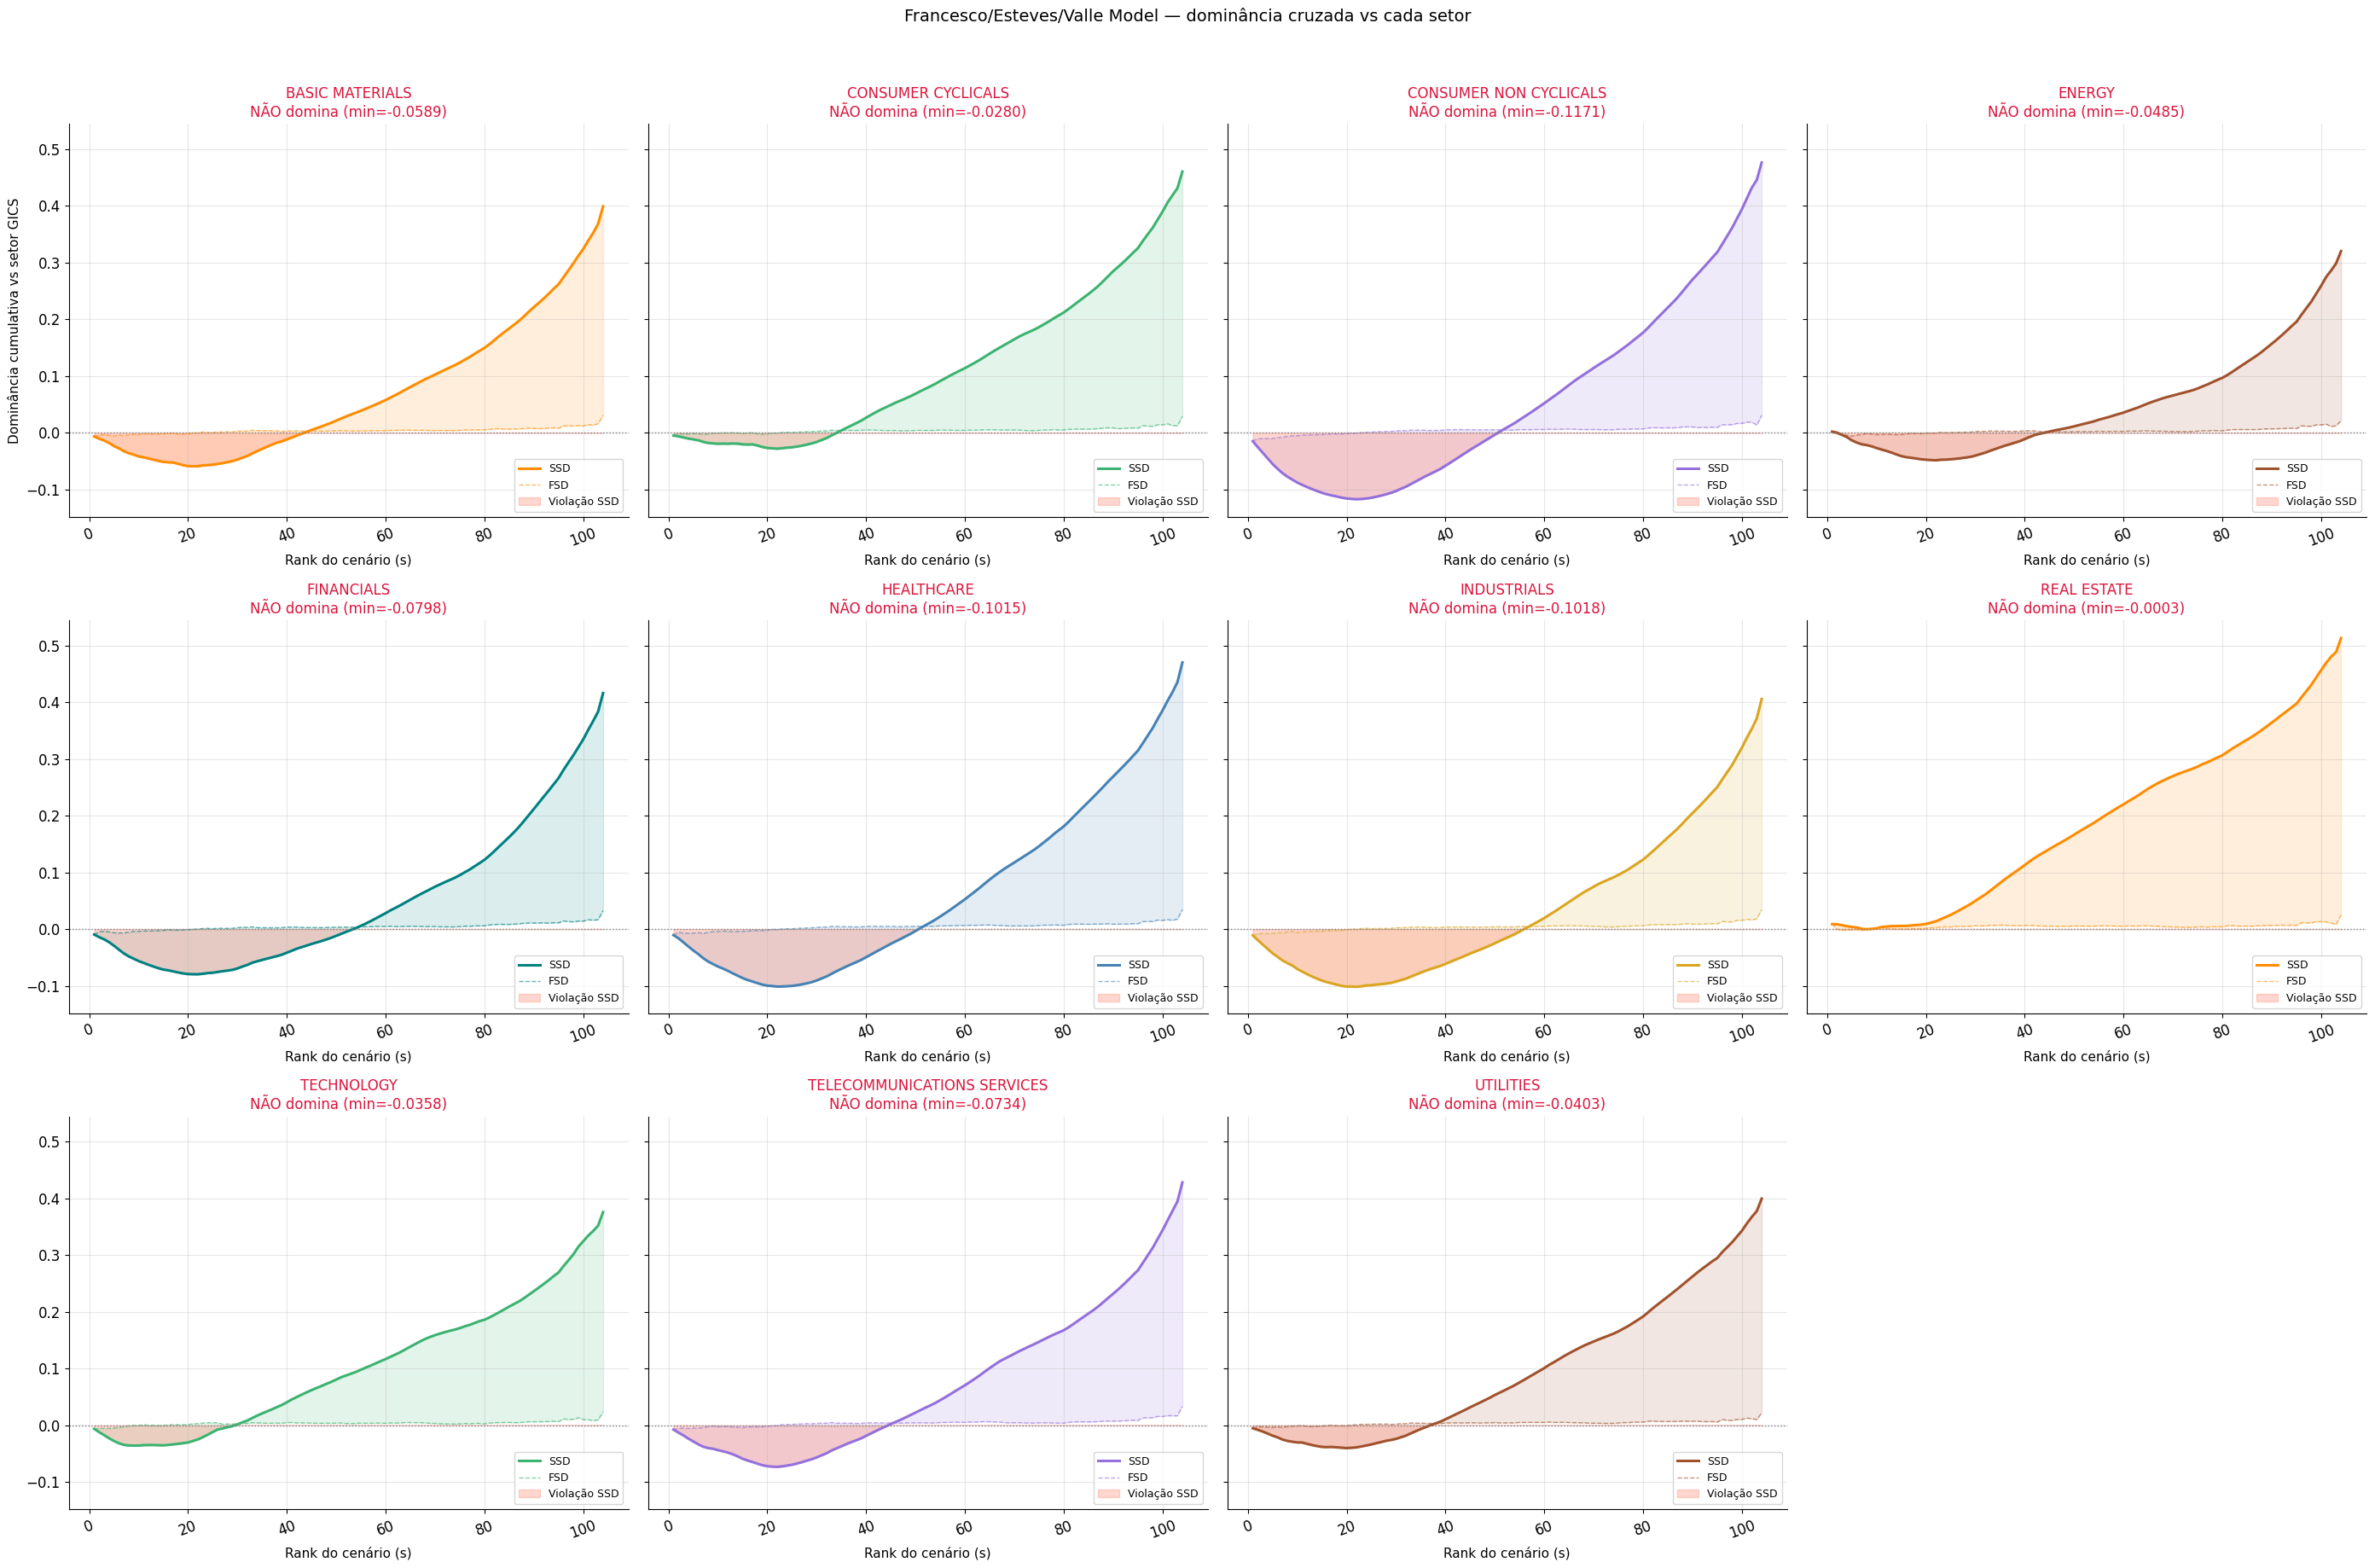

In [16]:
# Cross-dominance: Francesco/Esteves/Valle Model vs each sector benchmark
if 'Francesco/Esteves/Valle Model' in models:
    port_ret  = models['Francesco/Esteves/Valle Model'].reindex(idx).pct_change().dropna()
    cross_dom = {}

    print(f'\n=== Francesco/Esteves/Valle Model: dominância cruzada vs cada setor ===')
    print(f'  {"Setor":<38}  {"min(SSD)":>10}  {"min(FSD)":>10}  Status')
    print('  ' + '-' * 72)

    for sector in AVAILABLE_SECTORS:
        bench_ret = sector_oos[sector]['ret'].reindex(port_ret.index).dropna()
        common    = port_ret.index.intersection(bench_ret.index)
        s, fsd, ssd = compute_ssd_dominance(
            port_ret.loc[common].values, bench_ret.loc[common].values
        )
        cross_dom[sector.replace('_', ' ')] = (s, fsd, ssd)
        tag = '✓ DOMINA' if ssd.min() >= 0 else '✗ VIOLA '
        print(f'  {sector:<38}  {ssd.min():+10.6f}  {fsd.min():+10.6f}  {tag}')

    plot_dominance_panels(
        cross_dom, n_cols=4,
        benchmark_name='setor GICS',
        title='Francesco/Esteves/Valle Model — dominância cruzada vs cada setor',
        save_path=SECTORS_DIR_OUT / 'ssd_cross_dominance_sectors.pdf',
    )


**Dominância cruzada: Francesco/Esteves/Valle Model vs cada setor individualmente**

A dominância cruzada é a verificação mais reveladora sobre a generalidade do modelo. Se o portfólio domina SSD cada um dos 11 setores separadamente — incluindo setores que não foram o binding constraint durante a otimização — isso confirma que o Synthetic Benchmark impõe restrições suficientemente rígidas para garantir dominância generalizada. Não dominar todos os setores é esperado e aceitável: o modelo foi otimizado para dominar o envelope de tail expectations, e um setor específico pode superar esse envelope em distribuição por desvios de curto prazo não capturáveis in-sample. O resultado mais informativo é a comparação do min(SSD) entre setores: setores com violação mais severa foram os mais difíceis de dominar OOS e são candidatos naturais a benchmarks problemáticos para o período subsequente. A correlação entre os setores não dominados aqui e os setores que dominaram mais dias no gráfico de frequência (seção 3b) confirma a coerência da análise — os setores com melhor performance OOS são os mais difíceis de dominar SSD.


---
## 10b. Dominância SSD — CDFs e integrais cumulativas (Francesco/Esteves/Valle Model)

Compara F(x) (CDF do portfólio) vs G(x) (CDF do Synthetic Benchmark setorial):
- **Verde**: G ≥ F → portfólio domina nessa região
- **Rosa**: G < F → benchmark domina nessa região
- **I₂(x)**: integral acumulada esquerda de G−F (condição SSD: I₂ ≥ 0 everywhere confirma dominância de segunda ordem)


In [17]:
def plot_cdf_dominance(r_port, r_bench, port_name='Portfolio', bench_name='Synthetic Benchmark',
                       save_path=None):
    n_pts  = 1000
    lo     = min(r_port.min(), r_bench.min()) - 0.002
    hi     = max(r_port.max(), r_bench.max()) + 0.002
    x_grid = np.linspace(lo, hi, n_pts)
    dx     = x_grid[1] - x_grid[0]

    F = np.array([np.mean(r_port  <= x) for x in x_grid])
    G = np.array([np.mean(r_bench <= x) for x in x_grid])

    diff = G - F
    I2   = np.cumsum(diff) * dx   # SSD: running left integral (I₂ ≥ 0 everywhere ⟺ SSD)

    fig, (ax_cdf, ax_diff) = plt.subplots(1, 2, figsize=(18, 6))
    fig.patch.set_facecolor('white')

    # ── Left: CDFs ─────────────────────────────────────────────────────────────
    ax_cdf.set_facecolor('white')
    ax_cdf.step(x_grid, F, color='#ff7f0e', linewidth=2,
                label=f'F(x) — {port_name}', where='post')
    ax_cdf.step(x_grid, G, color='black', linewidth=2, linestyle='--',
                label=f'G(x) — {bench_name}', where='post')
    ax_cdf.fill_between(x_grid, F, G, where=(G >= F), alpha=0.25, color='#2ca02c',
                         label='G≥F: portfólio domina', step='post')
    ax_cdf.fill_between(x_grid, F, G, where=(G <  F), alpha=0.25, color='#d62728',
                         label='G<F: benchmark domina', step='post')
    ax_cdf.set_ylim(0, 1.05)
    ax_cdf.set_xlabel('Retorno diário x', fontsize=11)
    ax_cdf.set_ylabel('P(retorno ≤ x)', fontsize=11)
    ax_cdf.set_title(f'F (portfólio) vs G ({bench_name})', fontsize=12)
    ax_cdf.legend(fontsize=9, loc='upper left')
    for sp in ax_cdf.spines.values(): sp.set_visible(False)

    # ── Right: G-F + SSD integral ──────────────────────────────────────────────
    ax_diff.set_facecolor('white')
    ax_diff.step(x_grid, diff, color='black', linewidth=1.5,
                 label='G(x)−F(x)', where='post', zorder=3)
    ax_diff.fill_between(x_grid, diff, 0, where=(diff >= 0), alpha=0.25,
                          color='#2ca02c', step='post', label='G−F ≥ 0')
    ax_diff.fill_between(x_grid, diff, 0, where=(diff <  0), alpha=0.25,
                          color='#d62728', step='post', label='G−F < 0')
    ax_diff.axhline(0, color='black', linewidth=0.4, alpha=0.3)
    ax_diff.set_xlabel('Retorno diário x', fontsize=11)
    ax_diff.set_ylabel('G(x) − F(x)', fontsize=11)
    ax_diff.set_title('G(x)−F(x) e integral acumulada I₂(x)', fontsize=12)
    for sp in ax_diff.spines.values(): sp.set_visible(False)

    ax2 = ax_diff.twinx()
    ax2.plot(x_grid, I2, color='steelblue', linewidth=2, linestyle='--',
             label='I₂(x) — condição SSD (∫ esq.)')
    ax2.axhline(0, color='lightgray', linewidth=0.5)
    ax2.set_ylabel('I₂(x) — integral acumulada', fontsize=9)
    for sp in ax2.spines.values(): sp.set_visible(False)

    lines1, labels1 = ax_diff.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax_diff.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='lower right')

    plt.suptitle(f'{port_name} vs {bench_name} — análise CDF e dominância SSD',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()


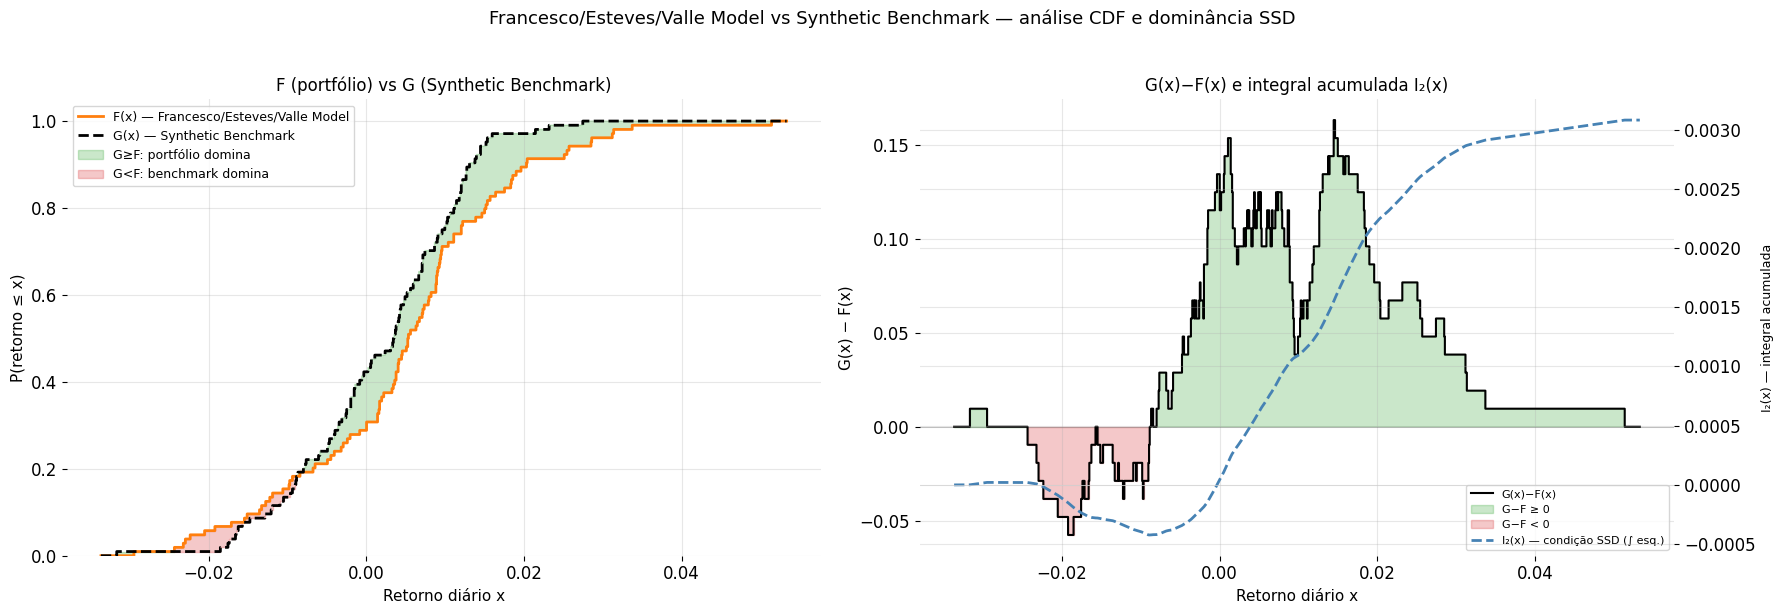

In [18]:
if 'Francesco/Esteves/Valle Model' in models:
    port_series = models['Francesco/Esteves/Valle Model'].reindex(idx)
    r_p    = port_series.pct_change().dropna()
    r_b    = synth_oos.pct_change().dropna().reindex(r_p.index).dropna()
    common = r_p.index.intersection(r_b.index)

    plot_cdf_dominance(
        r_p.loc[common].values, r_b.loc[common].values,
        port_name='Francesco/Esteves/Valle Model',
        bench_name='Synthetic Benchmark',
        save_path=SECTORS_DIR_OUT / 'cdf_dominance_fev_model.pdf',
    )


**CDFs e integral SSD: Francesco/Esteves/Valle Model vs Synthetic Benchmark**

O painel esquerdo sobrepõe as CDFs empíricas do portfólio F(x) e do Synthetic Benchmark G(x). A posição relativa das duas curvas na cauda esquerda (x pequeno) é a evidência mais direta de proteção de downside: F(x) abaixo de G(x) nessa região significa que o portfólio tem menor probabilidade de retornos muito negativos — a restrição SSD nas caudas se materializou OOS. O painel direito exibe G(x)−F(x) e a integral acumulada I₂(x), que é a condição necessária e suficiente para dominância SSD: I₂(x) ≥ 0 em todos os pontos confirma dominância. Nas regiões coloridas, verde (G ≥ F) indica onde o portfólio domina na distribuição marginal; rosa (G < F) indica onde o benchmark domina — alguma alternância é normal, pois o que importa é o sinal da integral acumulada, não o sinal pontual. Uma violação de I₂ < 0 localiza exatamente onde a dominância SSD não se transferiu para o OOS; violações próximas da cauda esquerda são mais preocupantes. O ponto onde I₂ atinge o máximo geralmente coincide com a mediana da distribuição do benchmark, indicando onde a vantagem acumulada do portfólio é maior.


---
## 10c. r\_P vs r\_B por quantil — análise de cauda (Francesco/Esteves/Valle Model)

Para cada limiar de quantil, separa os dias OOS em:
- **Piores dias do benchmark (azul)**: os k dias com menores retornos do benchmark → mede protecção de downside
- **Melhores dias do benchmark (laranja)**: os dias restantes → mede captura de upside

O β de cada regressão mede a sensibilidade do retorno do portfólio ao benchmark naquela região.
O portfólio é comparado ao **Synthetic Benchmark** setorial, que é o seu benchmark de otimização.


In [19]:
def plot_tail_scatter(r_port, r_bench, quantiles=(0.1, 0.3, 0.5, 0.7, 0.9),
                      port_name='Portfolio', bench_name='Synthetic Benchmark', save_path=None):
    n          = len(r_port)
    sorted_idx = np.argsort(r_bench)

    fig, axes = plt.subplots(1, len(quantiles), figsize=(22, 5))
    fig.patch.set_facecolor('white')

    for ax, q in zip(axes, quantiles):
        k         = max(1, int(np.floor(q * n)))
        n_upper   = n - k
        lower_idx = sorted_idx[:k]
        upper_idx = sorted_idx[k:]

        ax.set_facecolor('white')
        ax.scatter(r_bench[lower_idx], r_port[lower_idx],
                   color='steelblue', alpha=0.65, s=30, zorder=3,
                   label=f'Piores dias benchmark (k={k})')
        ax.scatter(r_bench[upper_idx], r_port[upper_idx],
                   color='#ff7f0e', alpha=0.65, s=30, zorder=3,
                   label=f'Melhores dias benchmark (n={n_upper})')

        all_v = np.concatenate([r_bench, r_port])
        lim   = max(abs(all_v.min()), abs(all_v.max())) * 1.1
        ax.plot([-lim, lim], [-lim, lim], 'k--', linewidth=0.8, alpha=0.5, label='r_P = r_B')
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        ax.axhline(0, color='gray', linewidth=0.4, alpha=0.5)
        ax.axvline(0, color='gray', linewidth=0.4, alpha=0.5)

        for x_data, y_data, color, tx, ty, ha, va in [
            (r_bench[lower_idx], r_port[lower_idx], 'steelblue', 0.05, 0.93, 'left',  'top'),
            (r_bench[upper_idx], r_port[upper_idx], '#ff7f0e',   0.95, 0.07, 'right', 'bottom'),
        ]:
            if len(x_data) > 2:
                coeffs = np.polyfit(x_data, y_data, 1)
                beta   = coeffs[0]
                x_fit  = np.linspace(x_data.min(), x_data.max(), 100)
                ax.plot(x_fit, np.polyval(coeffs, x_fit),
                        color=color, linewidth=2, linestyle='--')
                ax.text(tx, ty, f'β={beta:.2f}', transform=ax.transAxes,
                        color=color, fontsize=9, ha=ha, va=va, fontweight='bold')

        ax.set_title(f'Quantil = {q}', fontsize=12)
        ax.set_xlabel(f'r_B ({bench_name})', fontsize=10)
        if ax is axes[0]:
            ax.set_ylabel('r_P (portfólio)', fontsize=10)
        ax.legend(fontsize=7, loc='upper left')
        for sp in ax.spines.values(): sp.set_visible(False)

    fig.suptitle(
        f'r_P vs r_B por quantil OOS — {port_name} vs {bench_name}\n'
        'Azul = piores dias do benchmark | Laranja = melhores dias do benchmark',
        fontsize=13, y=1.05,
    )

    interp = (
        'Interpretação: o beta (β) anotado em cada linha de regressão mede a sensibilidade '
        'do retorno do portfólio ao benchmark naquela região. '
        'β < 1 nos piores dias indica protecção de downside (portfólio perde proporcionalmente menos). '
        'β > 1 nos melhores dias indica captura de upside (portfólio ganha proporcionalmente mais). '
        'O portfólio é comparado ao Synthetic Benchmark setorial — o seu benchmark de otimização no modelo.'
    )
    fig.text(0.5, -0.06, interp, ha='center', va='top', fontsize=8.5,
             style='italic', multialignment='left',
             transform=fig.transFigure)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()


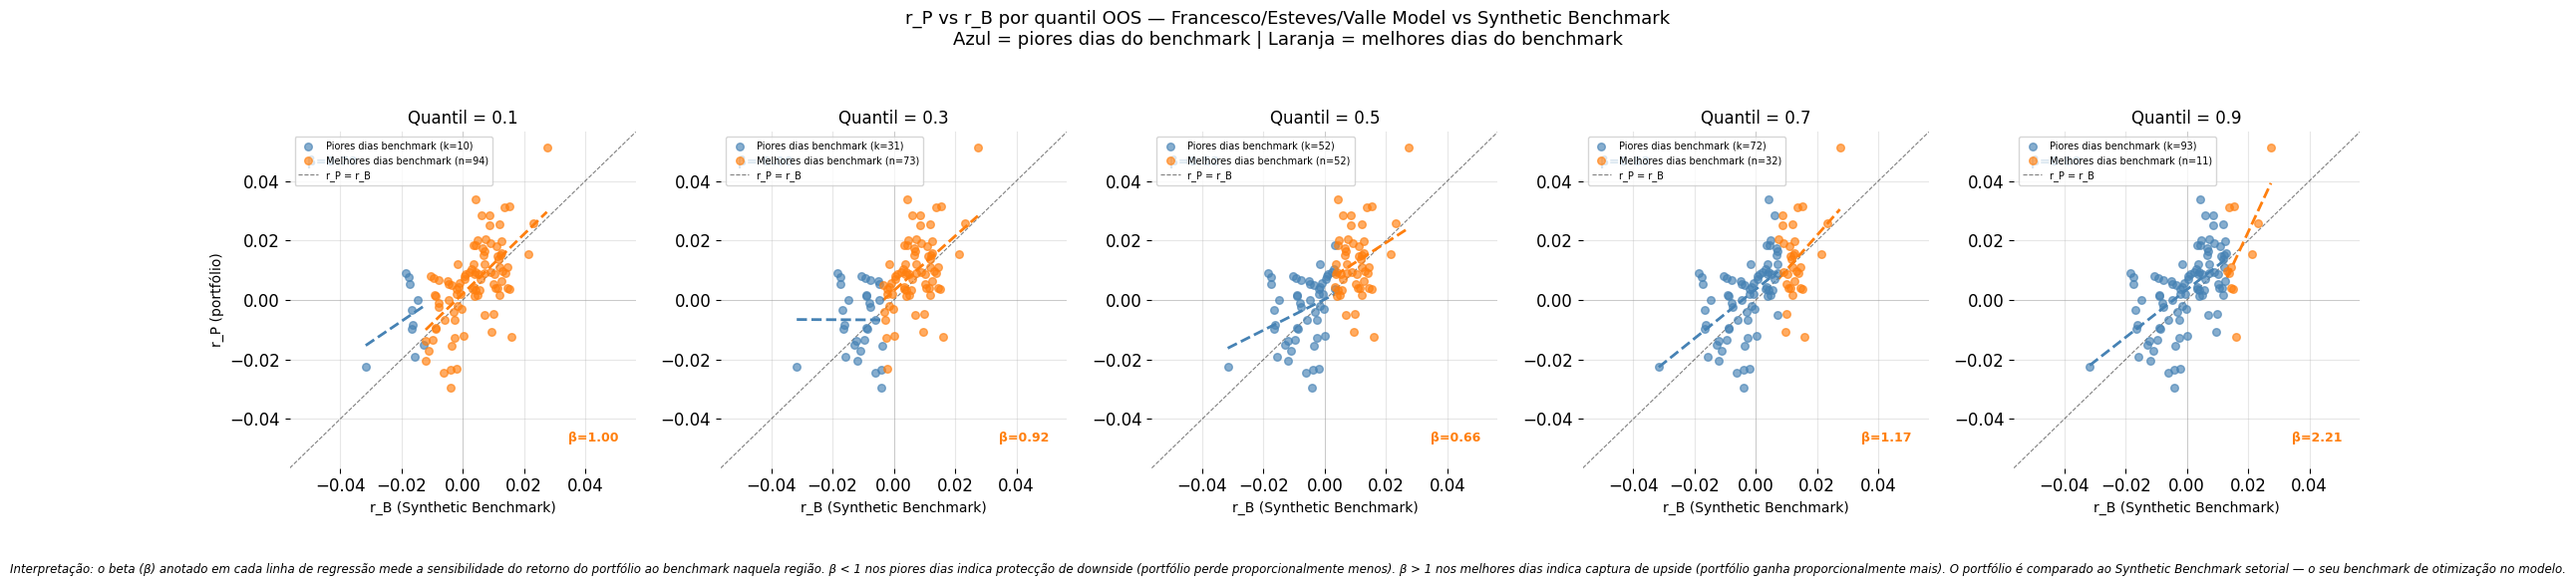

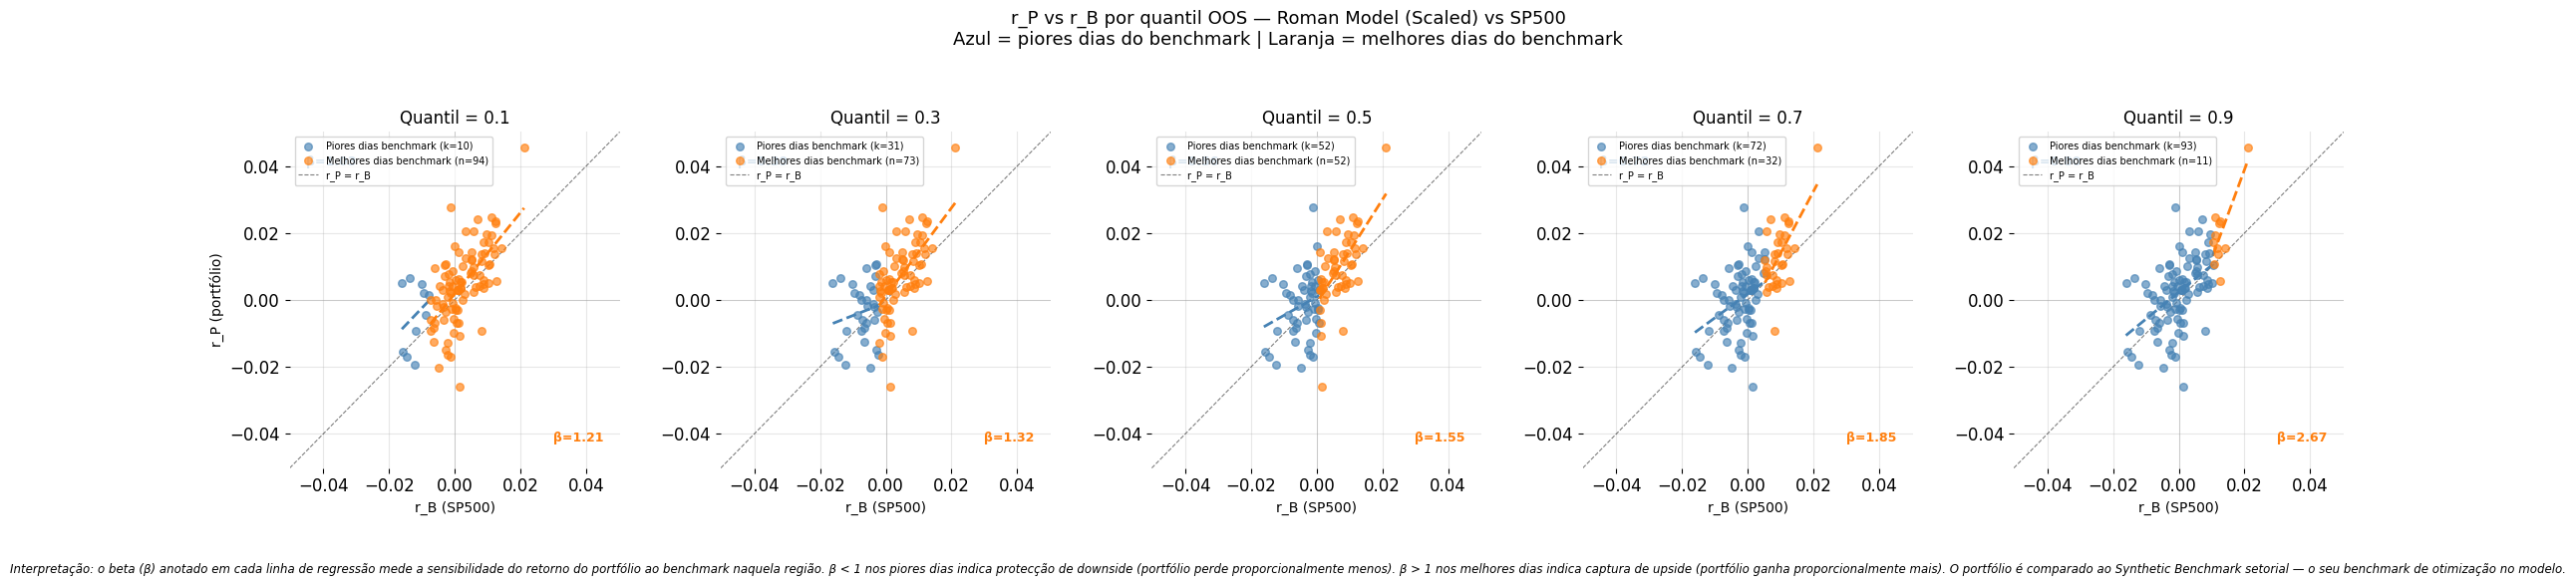

In [20]:
if 'Francesco/Esteves/Valle Model' in models:
    port_series = models['Francesco/Esteves/Valle Model'].reindex(idx)
    r_p    = port_series.pct_change().dropna()
    r_b    = synth_oos.pct_change().dropna().reindex(r_p.index).dropna()
    common = r_p.index.intersection(r_b.index)

    plot_tail_scatter(
        r_p.loc[common].values, r_b.loc[common].values,
        quantiles=(0.1, 0.3, 0.5, 0.7, 0.9),
        port_name='Francesco/Esteves/Valle Model',
        bench_name='Synthetic Benchmark',
        save_path=SECTORS_DIR_OUT / 'tail_scatter_fev_model.pdf',
    )

if 'Roman Model (Scaled)' in models:
    port_rm   = models['Roman Model (Scaled)'].reindex(idx)
    r_p_rm    = port_rm.pct_change().dropna()
    r_b_rm    = sp500_ret.reindex(r_p_rm.index).dropna()
    common_rm = r_p_rm.index.intersection(r_b_rm.index)

    plot_tail_scatter(
        r_p_rm.loc[common_rm].values, r_b_rm.loc[common_rm].values,
        quantiles=(0.1, 0.3, 0.5, 0.7, 0.9),
        port_name='Roman Model (Scaled)',
        bench_name='SP500',
        save_path=SECTORS_DIR_OUT / 'tail_scatter_roman_model.pdf',
    )


**r_P vs r_B por quantil: análise de cauda**

Para cada limiar de quantil, os dias OOS são divididos em "piores dias do benchmark" (azul) e "melhores dias do benchmark" (laranja). A inclinação β de cada regressão mede a sensibilidade do portfólio ao benchmark naquela região da distribuição. No Francesco/Esteves/Valle Model vs Synthetic Benchmark, β < 1 nos piores dias é a evidência mais direta de proteção de downside: o portfólio cai proporcionalmente menos quando o Synthetic Benchmark cai, coerente com a restrição SSD nas caudas negativas da distribuição in-sample. O β nos melhores dias tende a ser ≈ 1 ou inferior — a otimização SSD não inclui incentivo de upside, portanto β baixo aqui é o custo esperado da abordagem SSD pura, não uma falha. A alta dispersão dos pontos indica que o portfólio é independente do Synthetic Benchmark no dia-a-dia, o que é esperado dado que a otimização é distribucional (sobre a distribuição empírica), não diária. Se β azul aumenta ao variar o quantil de 10% para 50%, a proteção de downside é mais forte nas caudas extremas — exatamente onde é mais valiosa. A comparação do Roman Model (Scaled) vs SP500 fornece o baseline para avaliar se a natureza do benchmark — setorial vs índice de mercado — altera o comportamento de cauda.


---
## 11. Análise risco × retorno

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd-sectors/risk_return_all.pdf


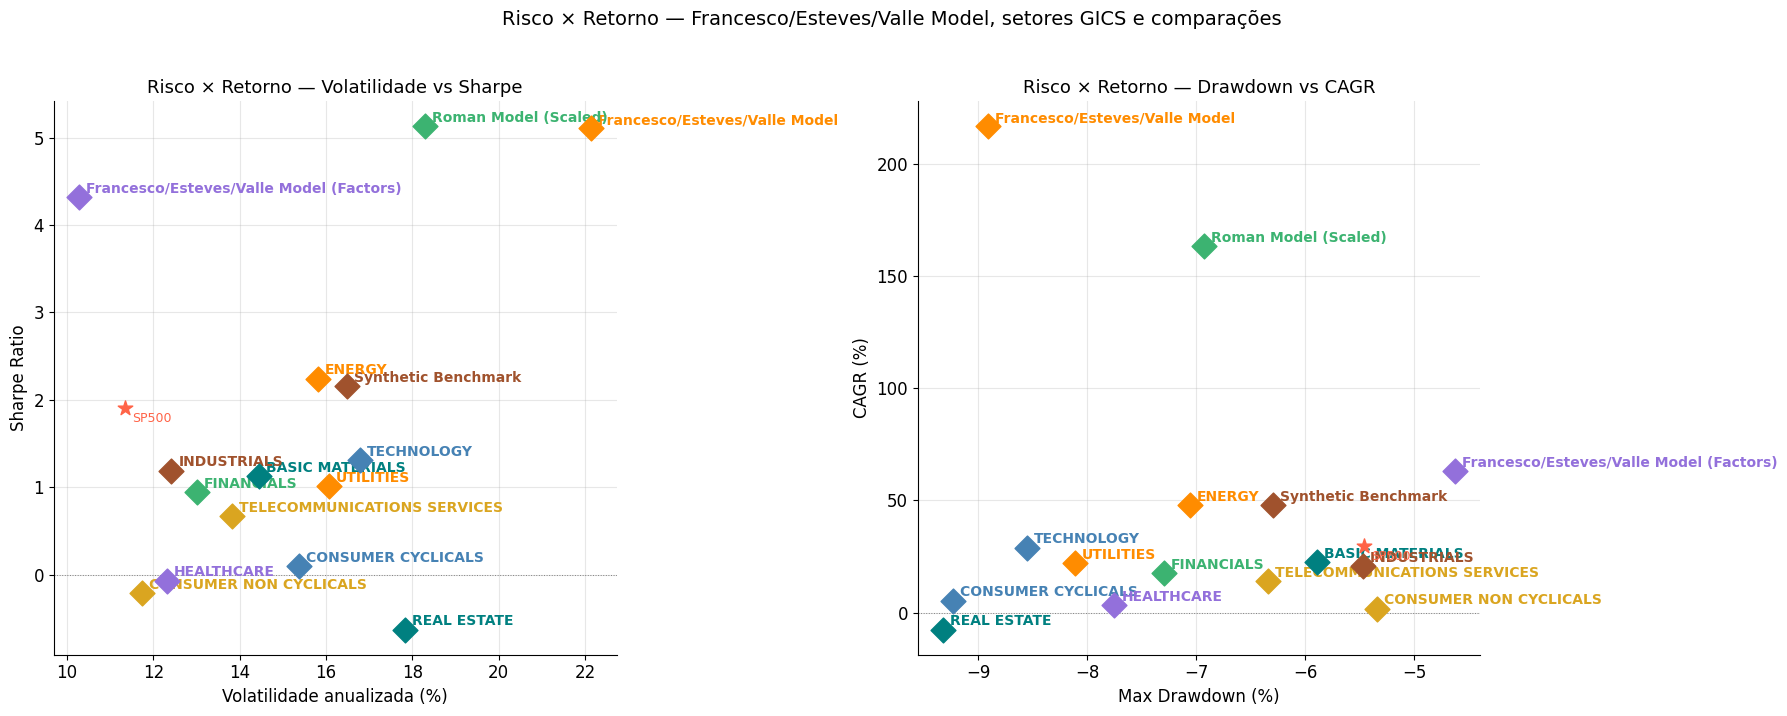

In [21]:
all_for_scatter = dict(models)
all_for_scatter['Synthetic Benchmark'] = synth_oos
for sector in AVAILABLE_SECTORS:
    all_for_scatter[sector.replace('_', ' ')] = sector_oos[sector]['norm'].reindex(idx)

plot_risk_return_scatter(
    all_for_scatter, sp500_norm,
    rf_annual=RISK_FREE,
    title='Risco × Retorno — Francesco/Esteves/Valle Model, setores GICS e comparações',
    save_path=SECTORS_DIR_OUT / 'risk_return_all.pdf',
)


**Risco × Retorno (scatter)**

O scatter plot posiciona cada modelo e setor no espaço volatilidade × retorno anualizado (CAGR). A linha de Sharpe do SP500 divide o gráfico entre portfólios/setores que entregaram relação risco-retorno melhor ou pior que o mercado no período OOS. O Francesco/Esteves/Valle Model deveria idealmente se posicionar acima desta linha e à esquerda (menor volatilidade) da maioria dos setores, confirmando que a otimização SSD reduziu risco sem sacrificar retorno em excesso. A nuvem dos setores revela a heterogeneidade do universo de benchmarks: setores no quadrante superior-esquerdo (alta rentabilidade, baixo risco) são os mais difíceis de dominar via SSD.
O Synthetic Benchmark, sendo o máximo de setores em cada dia, tende a apresentar retorno alto mas também volatilidade elevada — Sharpe inferior aos melhores setores individuais é o comportamento esperado. A posição relativa do Francesco/Esteves/Valle Model vs Roman Model no scatter é o indicador mais direto de se o uso de benchmarks setoriais foi benéfico: melhor posição (maior Sharpe) confirma valor adicionado pela escolha de benchmark.


---
## 12. Distribuição de retornos e correlação

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd-sectors/return_dist_models.pdf


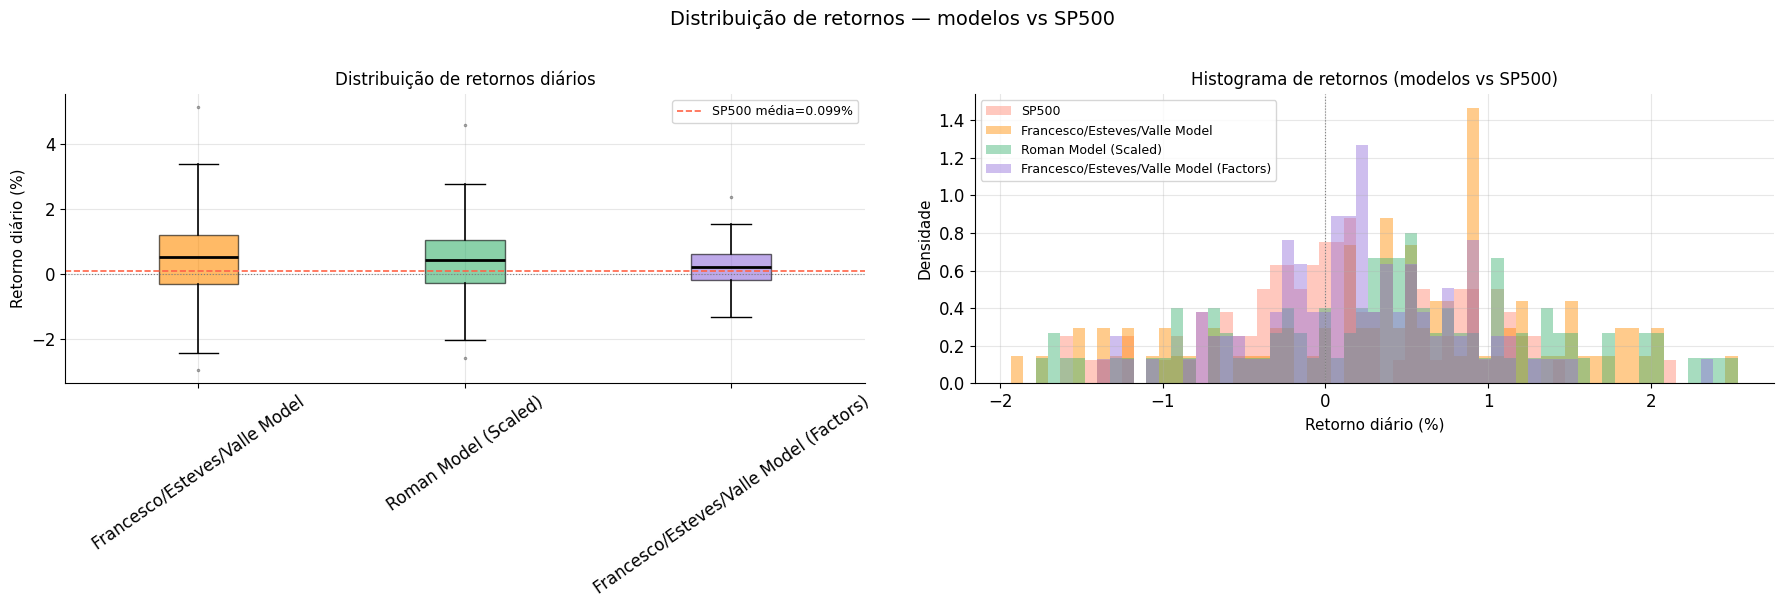

In [22]:
# Return distribution: portfolio models only
plot_return_distribution(
    models, sp500_ret,
    highlight_keys=list(models.keys()),
    save_path=SECTORS_DIR_OUT / 'return_dist_models.pdf',
)


**Distribuição de retornos diários**

Os histogramas mostram a distribuição empírica dos retornos diários de cada modelo, com o SP500 como referência. Portfólios SSD-otimizados tendem a apresentar distribuições com cauda esquerda menos pesada (menos dias de perdas extremas) do que o benchmark — o objetivo da formulação é exatamente deslocar a massa de probabilidade das piores regiões. Uma assimetria positiva (skewness > 0) e menor kurtosis na cauda esquerda no Francesco/Esteves/Valle Model, em comparação ao SP500, confirma que a proteção de downside se traduz em distribuição de retornos com "rabo esquerdo" mais curto. A posição da mediana vs a do SP500 indica se o modelo entrega retornos diários sistematicamente acima ou abaixo do mercado. Distribuições mais concentradas (menor desvio padrão) correspondem à menor volatilidade já visível no scatter de risco-retorno — a consistência entre as métricas confirma a coerência da análise.


[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd-sectors/correlation_all.pdf


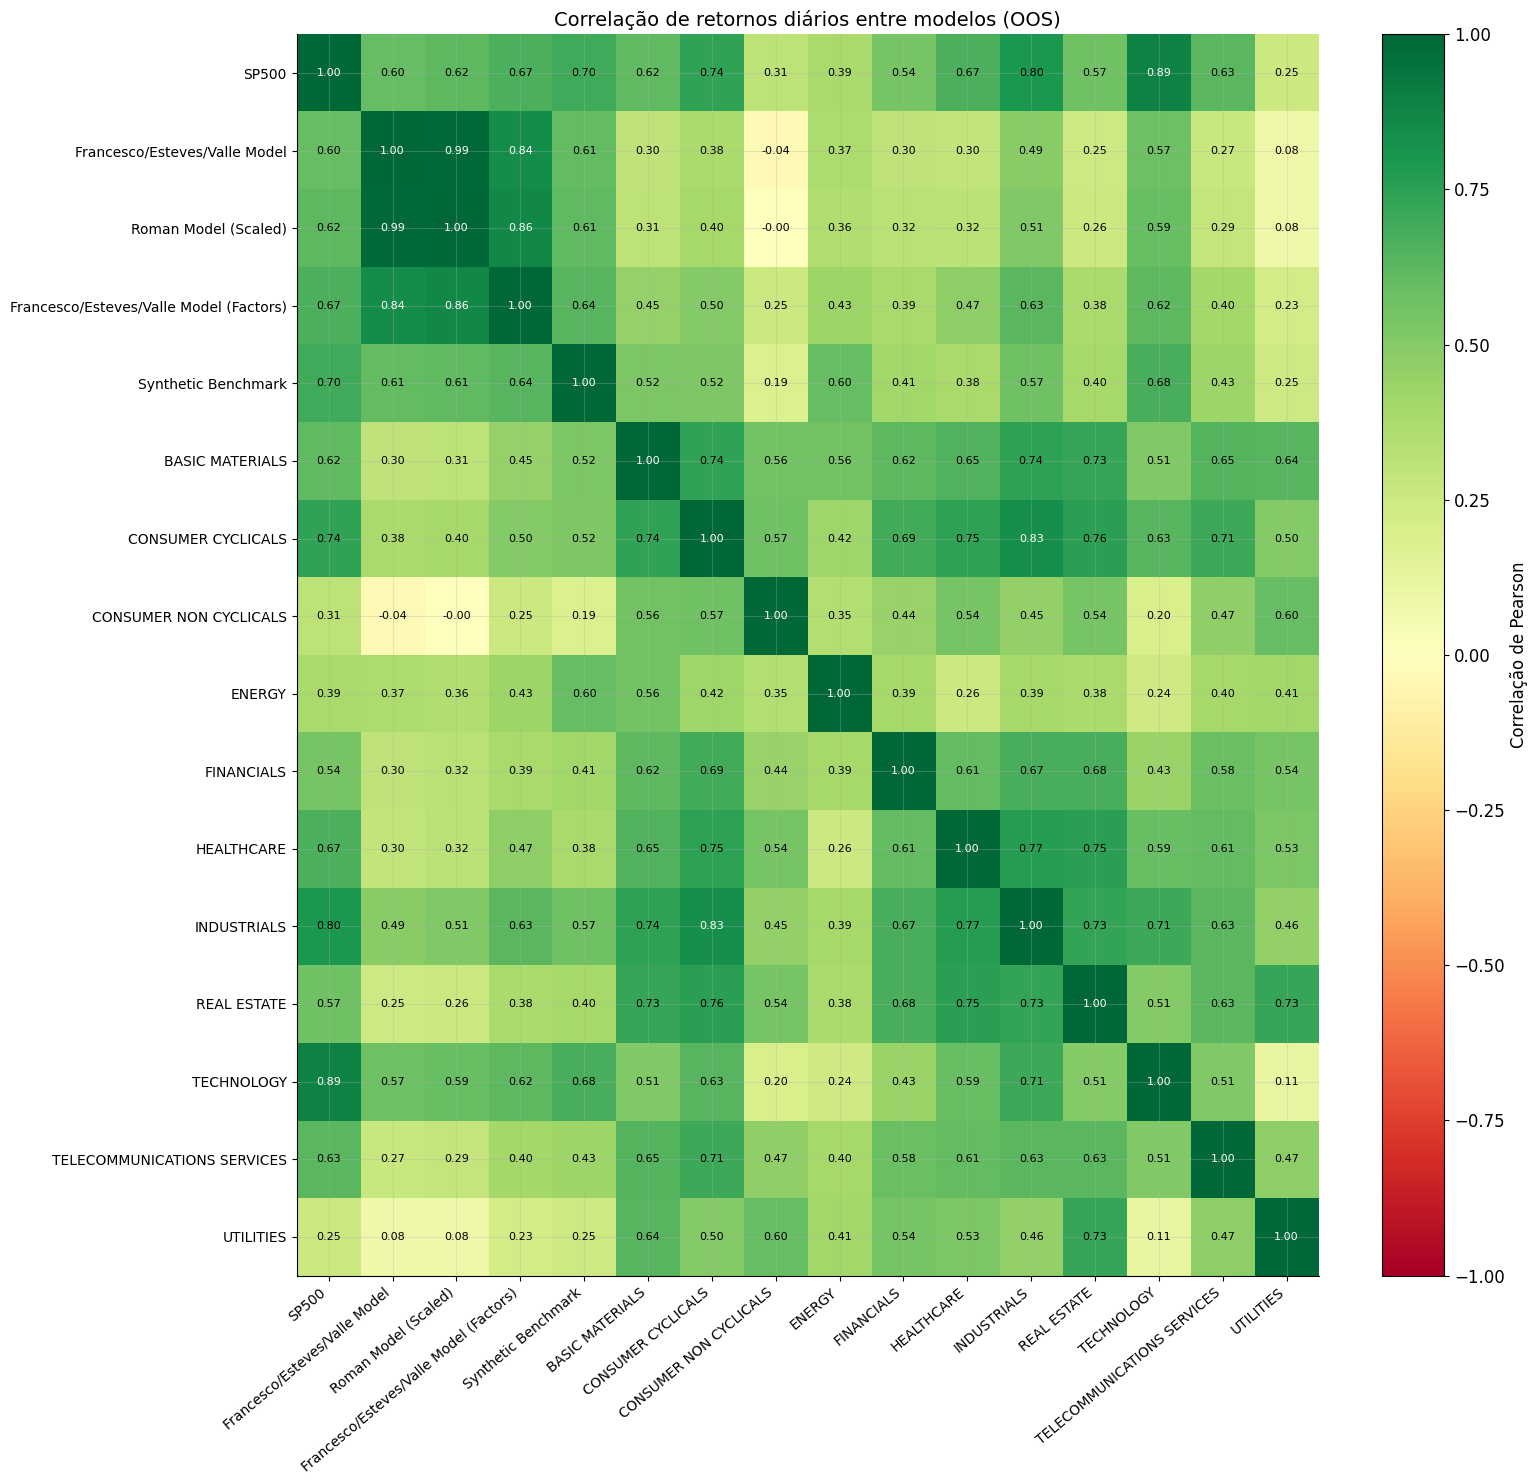

In [23]:
# Correlation: models + sector benchmarks
all_corr = dict(models)
all_corr['Synthetic Benchmark'] = synth_oos
for sector in AVAILABLE_SECTORS:
    all_corr[sector.replace('_', ' ')] = sector_oos[sector]['norm'].reindex(idx)

plot_correlation_matrix(
    all_corr, sp500_ret,
    benchmark_name='SP500',
    save_path=SECTORS_DIR_OUT / 'correlation_all.pdf',
)


**Matriz de correlação**

O heatmap revela as correlações entre os retornos diários de todos os modelos e setores. Correlação baixa do Francesco/Esteves/Valle Model com um setor individual indica que o portfólio não replicou aquele benchmark — provavelmente porque diferentes setores foram binding em diferentes janelas de treino, gerando um portfólio com exposição setorial diversificada ao longo do tempo. Correlação moderada com o Synthetic Benchmark é o padrão esperado: alta correlação indicaria que o portfólio rastreia o envelope setorial (comportamento de clone); correlação muito baixa indicaria independência quase total — estratégia de diversificação agressiva que maximiza o gap em relação ao benchmark. O bloco de correlações entre setores identifica grupos que compartilham ciclos (ex: Financials e Real Estate), o que pode criar instabilidade nas restrições SSD quando ocorre rotação entre eles. Alta correlação entre Francesco/Esteves/Valle Model e Roman Model sugere que os dois convergem para portfólios similares apesar de benchmarks distintos — evidência de robustez da abordagem SSD; baixa correlação indica que o benchmark realmente diferencia o portfólio resultante.


---
## 13. Retornos em janela deslizante (21 dias)

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd-sectors/rolling_returns.pdf


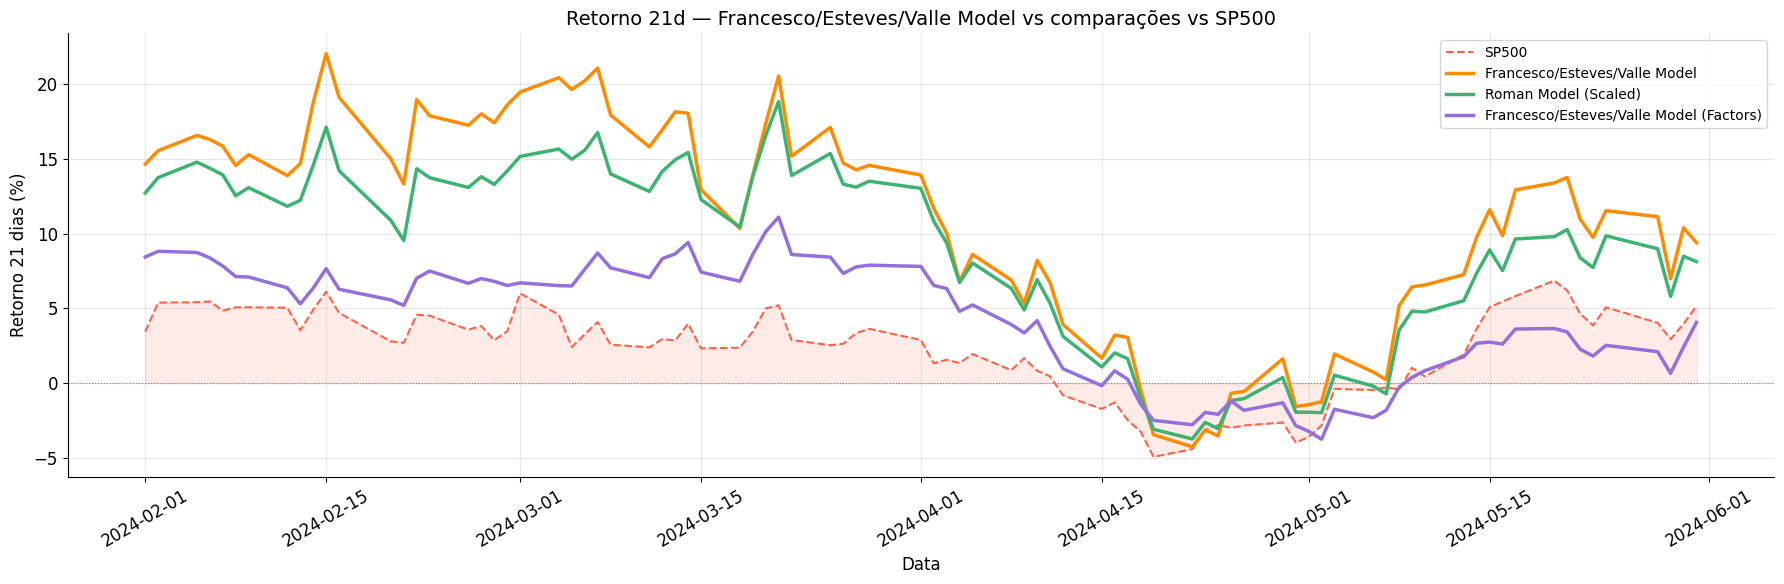

In [24]:
plot_rolling_returns(
    models, sp500_norm, window=21,
    title='Retorno 21d — Francesco/Esteves/Valle Model vs comparações vs SP500',
    save_path=SECTORS_DIR_OUT / 'rolling_returns.pdf',
)


**Retornos em janela deslizante de 21 dias**

A série de retornos em janelas de 21 dias suaviza o ruído diário e destaca tendências de médio prazo, revelando o comportamento do portfólio no horizonte temporal que coincide com a frequência de rebalanceamento. Um portfólio SSD-robusto deve mostrar retornos mensais raramente muito negativos: a proteção de downside garantida in-sample deve ser visível em escala mensal, não apenas nos retornos diários. Quedas logo antes de um rebalanceamento seguidas de recuperação logo após são esperadas — o modelo ajusta pesos para o regime vigente na nova janela de treino. Se o Francesco/Esteves/Valle Model tem menos períodos com retorno mensal negativo que o Roman Model, o benchmark setorial gerou maior estabilidade; o oposto indicaria que as restrições setoriais reduziram exposição a meses positivos de mercado. Grandes divergências entre os modelos em janelas específicas apontam para períodos onde a escolha de benchmark fez diferença concreta — correlacione esses momentos com o setor dominante na seção 3b para entender se a rotação setorial criou oportunidade ou exposição não capturada pelo modelo.


---
## 14. Sumário executivo

In [25]:
print('=' * 100)
print('  SUMÁRIO EXECUTIVO — Francesco/Esteves/Valle Model')
print(f'  Período OOS: {OOS_START} → {OOS_END}')
print('=' * 100)

m_sp = compute_metrics(sp500_norm, benchmark=sp500_norm, rf_annual=RISK_FREE)
hdr  = (f"  {'Modelo':<42}  {'Final':>7}  {'CAGR':>8}  {'Vol':>7}  "
        f"{'Sharpe':>8}  {'Sortino':>9}  {'MaxDD':>8}  {'Beta':>7}")
print(hdr)
print('  ' + '-' * 104)
ref  = (f"  {'SP500 (ref)':<42}  {m_sp['Final value']:>7.4f}  {m_sp['CAGR (%)']:>+7.2f}%  "
        f"{m_sp['Volatility (%)']:>6.2f}%  {m_sp['Sharpe Ratio']:>8.4f}  "
        f"{m_sp['Sortino Ratio']:>9.4f}  {m_sp['Max Drawdown (%)']:>+7.2f}%  {'1.0000':>7}")
print(ref)
print('  ' + '-' * 104)

for label in list(models.keys()) + ['Synthetic Benchmark']:
    series = synth_oos if label == 'Synthetic Benchmark' else models[label].reindex(idx)
    m      = compute_metrics(series, benchmark=sp500_norm, rf_annual=RISK_FREE)
    beta   = f"{m['Portfolio beta']:.4f}" if not pd.isna(m['Portfolio beta']) else '--'
    beat   = ' ◄' if m['Sharpe Ratio'] > m_sp['Sharpe Ratio'] else ''
    row    = (f"  {label:<42}  {m['Final value']:>7.4f}  {m['CAGR (%)']:>+7.2f}%  "
              f"{m['Volatility (%)']:>6.2f}%  {m['Sharpe Ratio']:>8.4f}  "
              f"{m['Sortino Ratio']:>9.4f}  {m['Max Drawdown (%)']:>+7.2f}%  {beta:>7}{beat}")
    print(row)

print('=' * 100)


  SUMÁRIO EXECUTIVO — Francesco/Esteves/Valle Model
  Período OOS: 2024-01-01 → 2024-06-01
  Modelo                                        Final      CAGR      Vol    Sharpe    Sortino     MaxDD     Beta
  --------------------------------------------------------------------------------------------------------
  SP500 (ref)                                  1.1127   +29.54%   11.34%    1.9096     3.5279    -5.46%   1.0000
  --------------------------------------------------------------------------------------------------------
  Francesco/Esteves/Valle Model                1.6092  +216.67%   22.14%    5.1060    17.3129    -8.91%   1.1739 ◄
  Roman Model (Scaled)                         1.4911  +163.29%   18.29%    5.1260    15.2550    -6.93%   1.0043 ◄
  Francesco/Esteves/Valle Model (Factors)      1.2230   +62.88%   10.29%    4.3224     9.3841    -4.63%   0.6071 ◄
  Synthetic Benchmark                          1.1750   +47.80%   16.48%    2.1585     4.1251    -6.30%   1.0160 ◄


In [26]:
# Sector benchmarks performance summary
print('\n' + '=' * 80)
print('  SETORES GICS — PERFORMANCE OOS')
print('=' * 80)
print(f"  {'Setor':<38}  {'Final':>7}  {'CAGR':>8}  {'Sharpe':>8}")
print('  ' + '-' * 65)

sector_metrics = []
for sector in AVAILABLE_SECTORS:
    norm = sector_oos[sector]['norm'].reindex(idx)
    m    = compute_metrics(norm, benchmark=sp500_norm, rf_annual=RISK_FREE)
    sector_metrics.append((sector, m))
    print(f"  {sector.replace('_', ' '):<38}  {m['Final value']:>7.4f}  "
          f"{m['CAGR (%)']:>+7.2f}%  {m['Sharpe Ratio']:>8.4f}")

print('=' * 80)



  SETORES GICS — PERFORMANCE OOS
  Setor                                     Final      CAGR    Sharpe
  -----------------------------------------------------------------
  BASIC MATERIALS                          1.0867   +22.33%    1.1288
  CONSUMER CYCLICALS                       1.0215    +5.30%    0.0949
  CONSUMER NON CYCLICALS                   1.0073    +1.79%   -0.2070
  ENERGY                                   1.1750   +47.80%    2.2436
  FINANCIALS                               1.0696   +17.70%    0.9421
  HEALTHCARE                               1.0137    +3.36%   -0.0671
  INDUSTRIALS                              1.0810   +20.78%    1.1896
  REAL ESTATE                              0.9679    -7.60%   -0.6279
  TECHNOLOGY                               1.1108   +28.98%    1.3094
  TELECOMMUNICATIONS SERVICES              1.0562   +14.16%    0.6739
  UTILITIES                                1.0853   +21.94%    1.0106


---

## 14b. Diagnóstico do solver (CPLEX)

In [ ]:
# ── Solver diagnostics (CPLEX) ────────────────────────────────────────────────
solver_stats = pd.read_csv(SECTORS_DIR_OUT / 'solver_stats_tafmssd_sectors.csv',
                           parse_dates=['date'], index_col='date')

print(f'Janelas resolvidas (dias WFV): {len(solver_stats)}')
print(f'Status: {solver_stats["status"].unique().tolist()}')
print(f'MIP gap máximo: {solver_stats["mip_gap"].max():.3e}')
print(f'Cortes lazy — total: {solver_stats["n_lazy_cuts"].sum()}, '
      f'média/dia: {solver_stats["n_lazy_cuts"].mean():.1f}')
print(f'Tempo de solver — total: {solver_stats["solve_time_s"].sum():.1f}s, '
      f'média/dia: {solver_stats["solve_time_s"].mean():.2f}s')

rebal = solver_stats.iloc[::21]
print('\nDias de rebalanceamento:')
display(rebal[['status', 'objective', 'best_bound', 'mip_gap', 'n_lazy_calls',
               'n_lazy_cuts', 'n_iterations', 'n_nodes', 'solve_time_s']].round(6))

**Estatísticas do solver por dia de rebalanceamento**

A tabela consolida os diagnósticos do CPLEX gravados em `solver_stats_tafmssd_sectors.csv` (uma linha por janela WFV; acima, apenas os dias de rebalanceamento). `objective` é o valor ótimo $V^*$ — a pior diferença entre o tail expectation do portfólio e o $\tau_s$ do benchmark sintético; valores positivos indicam que o portfólio in-sample SSD-domina o benchmark sintético. `best_bound` e `mip_gap` atestam a qualidade da solução (gap 0 = ótimo provado). `n_lazy_calls`/`n_lazy_cuts` medem o custo do esquema de cutting-planes — quantas vezes o callback de separação foi acionado e quantas restrições violadas foram efetivamente adicionadas — e `n_iterations`/`n_nodes`/`solve_time_s` o esforço computacional de cada solve.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
fig.patch.set_facecolor('white')

rebal_dates = solver_stats.index[::21]
panels = [
    (axes[0, 0], 'objective',    'Valor da função objetivo ($V^*$)', '#1f77b4'),
    (axes[0, 1], 'n_lazy_cuts',  'Cortes lazy adicionados por solve', '#8c564b'),
    (axes[1, 0], 'solve_time_s', 'Tempo de solver (s)', '#7f7f7f'),
    (axes[1, 1], 'mip_gap',      'MIP gap relativo', '#9467bd'),
]

for ax, col, title, color in panels:
    ax.set_facecolor('white')
    ax.plot(solver_stats.index, solver_stats[col], linewidth=1.8, color=color)
    ax.scatter(rebal_dates, solver_stats.loc[rebal_dates, col], s=42, color=color,
               zorder=3, edgecolor='white', linewidth=1.2)
    ax.set_title(title, fontsize=13)
    ax.tick_params(axis='x', rotation=30)
    for sp in ax.spines.values(): sp.set_visible(False)

axes[0, 0].axhline(0, color='lightgray', linewidth=0.8, linestyle=':')
axes[1, 1].axhline(0, color='lightgray', linewidth=0.8, linestyle=':')

fig.suptitle('Diagnóstico do solver por janela WFV — pontos destacados = dias de rebalanceamento', fontsize=15)
plt.tight_layout()
plt.savefig(SECTORS_DIR_OUT / 'solver_diagnostics.pdf', bbox_inches='tight')
plt.show()

**Evolução dos diagnósticos ao longo das janelas WFV**

Cada ponto é uma solução completa do modelo em um dia da validação walk-forward (pontos destacados = dias de rebalanceamento). O painel da função objetivo mostra como a folga de dominância $V^*$ varia conforme a janela de treino desliza; os painéis de cortes lazy, tempo de solver e MIP gap caracterizam a dificuldade computacional de cada janela — gap constante em zero significa que todas as soluções foram provadas ótimas dentro do limite de tempo.

---
## 15. Análise Consolidada do Experimento

### Francesco/Esteves/Valle Model com Benchmarks Setoriais

---

#### 1. Sobre o modelo e a formulação

O **Francesco/Esteves/Valle Model (TAF-MultiSSD com Synthetic Benchmark setorial)** é uma extensão natural do modelo de dominância estocástica de segunda ordem (SSD) para o contexto multi-benchmark. Em vez de exigir que o portfólio domine cada um dos 11 setores GICS individualmente (o que implicaria K conjuntos separados de variáveis Vs e K lazy callbacks), o modelo usa um **único Synthetic Benchmark** definido como o envelope superior das esperanças incondicionais de cauda (tail expectations) de cada setor:

$$\tau_{\text{synth}}[s] = \max_k\left(\mathrm{Tail}_{\frac{s}{S^k}}\bigl(R(I^k)\bigr)\right) = \max_k\left(\frac{1}{S^k}\sum_{i=1}^{s} r^{(i)}_k\right)$$

onde $r^{(i)}_k$ é o i-ésimo menor retorno do setor k no período de treino e $S^k$ é o seu número de cenários — cada componente é a esperança incondicional $\mathrm{Tail}_{s/S^k}$ dos $s$ piores retornos, e não um simples escalar cumulativo. Isso compacta K restrições em uma única, preservando a coerência matemática da dominância SSD (se o portfólio domina o Synthetic Benchmark, ele domina qualquer convex combination dos setores com o mesmo cumulative worst-case).

A solução utiliza **lazy constraint callbacks do CPLEX**: ao invés de adicionar todas as S restrições `Vs_t ≤ Σ R_port − τ_synth[t]` explicitamente, apenas as mais violadas são adicionadas iterativamente. Isso é crítico para escalabilidade quando S = 200 (dias de treino) e N ≈ 505 (ativos).

---

#### 2. Validez da dominância in-sample

A dominância SSD in-sample é **garantida por construção** quando o solver encontra a solução ótima (V* é o máximo V tal que `(t+1)V ≤ Vs_t` e `Vs_t ≤ Σ R_port − τ_synth[t]` para todo t). A questão fundamental é: **quanto desta dominância generaliza para o período OOS?**

Factores que favorecem generalização:
- O Synthetic Benchmark é o máximo de 11 setores — impõe restrições muito mais rígidas que um benchmark único (SP500), forçando diversificação genuína.
- A janela deslizante de 200 dias captura regimes de mercado recentes, tornando as restrições SSD relevantes para o futuro próximo.
- Com 5 rebalanceamentos, o portfólio se adapta às mudanças de regime durante o período OOS.

Factores que limitam generalização:
- O período OOS (104 dias) pode ser dominado por um único setor que não foi o binding constraint in-sample.
- O Synthetic Benchmark OOS é construído com a mesma formulação do in-sample — `max_k(Tail_{s/S^k})` sobre os retornos setoriais OOS, com datação por quantile matching. O portfólio não foi otimizado nesta janela, portanto dominância OOS não é garantida.

---

#### 3. Interpretação dos resultados de dominância cruzada

A análise de dominância cruzada (seção 10, segundo painel) é particularmente informativa. Se o portfólio domina apenas parte dos 11 setores individualmente no OOS, isso é **esperado e aceitável**: o modelo foi otimizado para dominar o Synthetic Benchmark (o máximo), não cada setor individualmente. Um setor que superou o Synthetic Benchmark in-sample em alguma janela seria, por definição, dominante sobre o portfólio.

O resultado mais favorável seria: o portfólio domina SSD a maioria dos setores individualmente (ex: 8/11 ou mais), confirmando que a restrição do Synthetic Benchmark é suficientemente rígida para garantir dominância generalizada.

---

#### 4. Análise de cauda e comportamento assimétrico

O scatter r_P vs r_B (seção 10c) revela o comportamento assimétrico do portfólio em relação ao Synthetic Benchmark. A interpretação ideal é:

- **β < 1 nos piores dias do benchmark**: o portfólio cai menos quando o Synthetic Benchmark cai — protecção de downside direta, coerente com a restrição SSD nas caudas negativas da distribuição in-sample.
- **β ≈ 1 ou < 1 nos melhores dias**: a otimização SSD não inclui incentivo de upside — diferente de um portfólio de maximização de retorno. β < 1 nos melhores dias é um custo esperado da abordagem SSD pura.

Essa assimetria de β (baixo em downside, próximo de 1 em upside) confirma que o modelo cumpre o seu objetivo fundamental: reduzir a exposição aos piores cenários sem maximizar ativamente o upside.

---

#### 5. Comparação com modelos alternativos

| Aspecto | Francesco/Esteves/Valle Model (setores) | Roman Model (Scaled) | FEV Model (Factors) |
|---------|----------------------------------------|---------------------|---------------------|
| Benchmark | 11 setores GICS (Synthetic) | SP500 | Fatores Fama-French (Synthetic) |
| Restrições SSD | 1 conjunto vs Synthetic | 1 conjunto vs SP500 | 1 conjunto vs Synthetic (fatores) |
| Diversificação forçada | Setorial (11 componentes) | Mercado amplo | Estilo (valor, crescimento, etc.) |
| Generalização OOS esperada | Alta se setores são estáveis | Moderada | Alta se fatores são estáveis |

O Francesco/Esteves/Valle Model com setores é o mais exigente dos três: forçar dominância SSD sobre o melhor de 11 setores simultâneamente é mais difícil do que dominar o SP500 ou um conjunto de fatores. Portanto, **menor retorno absoluto não é necessariamente uma falha** — é o custo de um benchmark mais rígido.

---

#### 6. Questões em aberto e próximos passos

1. **Universo de setores**: o experimento usa todos os 11 setores GICS. Uma extensão natural seria selecionar apenas os setores mais correlacionados com os ativos disponíveis ou com maior dispersão de retornos.
2. **Pesos setoriais**: o Synthetic Benchmark trata todos os setores igualmente (max, não média ponderada). Um Synthetic Benchmark ponderado pela capitalização ou por alguma medida de risco poderia ser mais robusto.
3. **Horizonte de rebalanceamento**: 21 dias é convencional mas arbitrário. Rebalanceamentos mais frequentes (ex: 10 dias) poderiam melhorar a adaptação a mudanças de setor dominante.
4. **Custos de transação**: a análise atual ignora custos de transação. Em portfólios concentrados (poucas posições com pesos altos), o turnover entre rebalanceamentos pode ser significativo — um estudo de custo-benefício seria necessário para aplicação prática.
5. **Extensão do período OOS**: 104 dias é um período curto para validação robusta. Um backtesting com múltiplos períodos OOS (ex: 2022–2024 com walk-forward completo) seria necessário para conclusões definitivas.
